# From External Correction to Internal Alignment: Embedding Reliable Reasoning in Large Language Models

### Phase 0: Setup & Resource Management


1. ✅ Select a Base Model: Choose a lightweight, open-source LLM suitable for reasoning tasks that fits your compute budget (e.g., Llama-3-8B, Gemma-2-9B, or Qwen-2.5-7B).

2. ✅ Set up Environment: Install necessary libraries (PyTorch, Hugging Face transformers, datasets, and likely trl for preference optimization).

3. ✅ Download Base Model: Download the weights of your chosen base model from Hugging Face.

4. ✅ Select Target Task: Choose a specific reasoning task (e.g., math or logic) to serve as the "prompt" for your dataset.


5. ✅ Download Source Dataset: Download an existing dataset (like GSM8K or CommonsenseQA) to provide the initial questions/prompts.

### Phase 1: Data Generation & CPO Fine-Tuning

* ✅ Generate "Unpreferred" Data: Run inference using your Base Model on the source dataset to generate incorrect chains-of-thought and answers.


* ✅ Generate "Preferred" Data: Use the ground truth from your source dataset, or use a stronger model (like GPT-4o or Claude 3.5 Sonnet via API) to generate correct chains-of-thought if the dataset lacks them.


* ✅ Format Triplet Dataset: Compile the data into the required JSON format: `{prompt, preferred_completion, unpreferred_completion}` .

* ✅ Run CPO Fine-Tuning:

  * ✅ Load the Base Model.

  * ✅ Apply Contrastive Preference Optimization (CPO) loss to maximize the probability of preferred completions and minimize unpreferred ones.

  * ✅ Save Model: Save this new fine-tuned model as "Model-CPO".

### Phase 2: SAE-Based Interpretability

* ✅ Data Collection for SAE: Run a subset of data through both the Base Model and Model-CPO and save the internal activations (hidden states).


* ✅ Train SAE 1 (Base): Train a Sparse Autoencoder on the activations collected from the Base Model.


* ✅ Train SAE 2 (CPO): Train the same Sparse Autoencoder on the activations collected from Model-CPO.

  * Resource Note: SAE training can be memory-intensive; consider training on a specific layer known for reasoning (like middle-to-late layers) rather than all layers to save resources.

* Feature Analysis:

  * Compare the features active in SAE 1 vs. SAE 2.

  * Identify specific features that represent errors (suppressed in CPO) or corrections (strengthened in CPO).

* Feature Steering (Intervention):

  * Load the Base Model.

  * Feed it a prompt that usually results in an error.

  * Manually activate the "correction feature" identified during your analysis of Model-CPO.

  * Verify if this intervention forces the Base Model to produce the correct reasoning.

### Phase 3: Baseline Comparison (Ablation) (Optional)

* Prepare Negative Dataset: Filter your dataset to isolate the `unpreferred_completion data`.
* Train Baseline Model:
  * Load a fresh instance of the Base Model.
  
  * Fine-tune it using Unlikelihood Loss ($L_{UL}$) specifically on the negative data to penalize incorrect tokens.
  
* Compare Results: Compare the performance of this baseline model against your Model-CPO to validate that CPO is the superior method16.

## Phase 0: Setup & Resource Management

In [ ]:
from google.colab import drive
from google.colab import runtime
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q -U bitsandbytes

!pip install -q -U xformers trl peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 141.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from huggingface_hub import login
from google.colab import userdata
from trl import CPOTrainer, CPOConfig
import matplotlib.pyplot as plt

In [ ]:
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token, add_to_git_credential=True)

In [ ]:
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
DEVICE_MAP = "auto"

# Quantization Config (Recommended for Colab)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token



tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
%%script true

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)

print(f"Successfully loaded {MODEL_ID}")
print(f"Model is executing on: {model.device}")

### Dataset:

We are using the GSM8k for now. We will focus on math problems mostly. Other datasets we can use later on are:

1. GSM-hard: Harder version of GSM8k
2. CommonsenseQA: A Logic dataset, not Math.

In [ ]:
from datasets import load_dataset

dataset = load_dataset("gsm8k", "main")

print("Dataset Structure:")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})


In [ ]:
import pandas as pd

df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()

print(f"Shape: {df_train.shape}")
display(df_train.head())

Shape: (7473, 2)


,question,answer
0,Natalia sold clips to 48 of her friends in Apr...,Natalia sold 48/2 = <<48/2=24>>24 clips in May...
1,Weng earns $12 an hour for babysitting. Yester...,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...
2,Betty is saving money for a new wallet which c...,"In the beginning, Betty has only 100 / 2 = $<<..."
3,"Julie is reading a 120-page book. Yesterday, s...",Maila read 12 x 2 = <<12*2=24>>24 pages today....
4,James writes a 3-page letter to 2 different fr...,He writes each friend 3*2=<<3*2=6>>6 pages a w...


### Function to extract COT steps from the 'answer' column in df

In [ ]:
import re
from pprint import pprint
from typing import List, Tuple

def extract_last_number_from_text(text) -> float:
  text=text.replace(',', '')
  numbers = re.findall(r'-?\d+', text)
  if numbers:
    return float(numbers[-1])
  return 0.0

def extract_steps_from_answer(answer) -> Tuple[List[str], List[float]]:
  answer_lines = answer.split('\n')
  cot_steps = []
  step_answers = []
  for line_number, line in enumerate(answer_lines):
    line = line.strip()
    line = re.sub(r'<<.*?>>', '', line)
    line = re.sub(r'#+ ', '', line)

    step_answers.append(extract_last_number_from_text(line))

    if line_number == len(answer_lines) - 1:
      cot_steps.append(f'Final Answer: {line}')
      continue
    cot_steps.append(f'Step {line_number + 1}: {line}')

  return cot_steps, step_answers

def extract_cot_steps(df):
  question = df['question']
  answer = df['answer']
  cot_steps_dict = []

  for q, a in zip(question, answer):
    cot_steps, step_answers = extract_steps_from_answer(a)
    final_answer = extract_last_number_from_text(a)
    cot_steps_dict.append({
        'question': q,
        'true_cot_steps': cot_steps,
        'true_step_answers': step_answers,
        'true_final_answer': final_answer
    })

  return cot_steps_dict




In [ ]:
def convert_to_cot_df(df):
  cot_steps_dict = extract_cot_steps(df)
  return pd.DataFrame(cot_steps_dict)

df_train_cot = convert_to_cot_df(df_train)
df_train_cot.head()

,question,true_cot_steps,true_step_answers,true_final_answer
0,Natalia sold clips to 48 of her friends in Apr...,"[Step 1: Natalia sold 48/2 = 24 clips in May.,...","[24.0, 72.0, 72.0]",72.0
1,Weng earns $12 an hour for babysitting. Yester...,"[Step 1: Weng earns 12/60 = $0.2 per minute., ...","[2.0, 10.0, 10.0]",10.0
2,Betty is saving money for a new wallet which c...,"[Step 1: In the beginning, Betty has only 100 ...","[50.0, 30.0, 5.0, 5.0]",5.0
3,"Julie is reading a 120-page book. Yesterday, s...","[Step 1: Maila read 12 x 2 = 24 pages today., ...","[24.0, 36.0, 84.0, 42.0, 42.0]",42.0
4,James writes a 3-page letter to 2 different fr...,[Step 1: He writes each friend 3*2=6 pages a w...,"[6.0, 12.0, 624.0, 624.0]",624.0


In [ ]:
df_test_cot = convert_to_cot_df(df_test)
df_test_cot.head()

,question,true_cot_steps,true_step_answers,true_final_answer
0,Janet’s ducks lay 16 eggs per day. She eats th...,[Step 1: Janet sells 16 - 3 - 4 = 9 duck eggs ...,"[9.0, 18.0, 18.0]",18.0
1,A robe takes 2 bolts of blue fiber and half th...,"[Step 1: It takes 2/2=1 bolt of white fiber, S...","[1.0, 3.0, 3.0]",3.0
2,Josh decides to try flipping a house. He buys...,[Step 1: The cost of the house and repairs cam...,"[130000.0, 120000.0, 200000.0, 70000.0, 70000.0]",70000.0
3,James decides to run 3 sprints 3 times a week....,"[Step 1: He sprints 3*3=9 times, Step 2: So he...","[9.0, 540.0, 540.0]",540.0
4,"Every day, Wendi feeds each of her chickens th...",[Step 1: If each chicken eats 3 cups of feed p...,"[60.0, 20.0, 20.0]",20.0


### Pipeline for LLM generation of COT steps

#### Example to give in prompt:

In [ ]:
example_df = df_train_cot.iloc[0]

prefix = f'''Answer the following question step-by-step.
Write the steps as "Step X: ..."
Write the final answer as "Final Answer: ..."

Question: {example_df['question']}
Solution:
'''
for step in example_df['true_cot_steps']:
  prefix += f'''{step}
'''

print(prefix)

Answer the following question step-by-step.
Write the steps as "Step X: ..."
Write the final answer as "Final Answer: ..."

Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Solution:
Step 1: Natalia sold 48/2 = 24 clips in May.
Step 2: Natalia sold 48+24 = 72 clips altogether in April and May.
Final Answer: 72



### Generating Example Answers

In [ ]:
import re

def get_step_data(complete_response):
  # Modified regex: captures text starting with 'Step X:' OR 'Final Answer:'
  # It stops capturing when it sees the next 'Step', 'Final Answer', or End of String.
  pattern = r'((?:Step \d+|Final Answer):.*?)(?=(?:Step \d+|Final Answer):|$)'

  steps = re.findall(pattern, complete_response, re.DOTALL)
  steps = [step.strip() for step in steps]

  step_answers = [extract_last_number_from_text(step) for step in steps]
  final_answer = extract_last_number_from_text(complete_response)

  return steps, step_answers, final_answer

def generate_full_prompt(initial_prompt):
  return f'''{prefix}

Question: {initial_prompt}
Solution:
'''

In [ ]:
from tqdm.notebook import tqdm
import torch
import pandas as pd

def generate_answers_batched(df, batch_size=4, num_responses=1):
  results = []
  tokenizer.padding_side = "left"
  questions = df['question'].tolist()
  true_final_answers = df['true_final_answer'].tolist()
  true_cot_steps = df['true_cot_steps'].tolist()
  true_step_answers = df['true_step_answers'].tolist()

  for i in tqdm(range(0, len(questions), batch_size), desc="Processing Batches"):

    batch_questions = questions[i : i + batch_size]

    batch_prompts = [generate_full_prompt(q) for q in batch_questions]

    inputs = tokenizer(
        batch_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    prompt_length = inputs['input_ids'].shape[1]

    with torch.no_grad():
      outputs = model.generate(
          **inputs,
          max_new_tokens=250,
          do_sample=True,
          temperature=1.0,
          pad_token_id=tokenizer.pad_token_id,
          num_return_sequences=num_responses
      )

    generated_tokens = outputs[:, prompt_length:]

    generated_texts = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

    for j, question in enumerate(batch_questions):
        start_idx = j * num_responses
        end_idx = start_idx + num_responses
        responses = generated_texts[start_idx : end_idx]

        true_cot_step = true_cot_steps[i + j]
        true_step_answer = true_step_answers[i + j]
        true_final_answer = true_final_answers[i + j]

        for response in responses:

          response = response.split('Question')[0].strip()

          generated_steps, generated_step_answers, generated_final_answer = get_step_data(response)

          results.append({
            'index': i + j + 1,
            'question': question,
            'true_cot_steps': true_cot_step,
            'true_step_answers': true_step_answer,
            'true_final_answer': true_final_answer,
            'generated_response': response,
            'generated_step_answers': generated_step_answers,
            'generated_cot_steps': generated_steps,
            'generated_final_answer': generated_final_answer,
            'is_correct': generated_final_answer == true_final_answer
          })

  return pd.DataFrame(results)


 Dividing the entire data into 10 pieces / batches so that if the model fails in the middle, generation won't have to start from the beginning.

In [ ]:
import numpy as np
import os

parts = np.array_split(df_train_cot, 10)
[part.shape for part in parts]

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


[(748, 4),
 (748, 4),
 (748, 4),
 (747, 4),
 (747, 4),
 (747, 4),
 (747, 4),
 (747, 4),
 (747, 4),
 (747, 4)]

In [ ]:
%%script true

generate_answers_p1 = generate_answers_batched(parts[0], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p1.csv'
generate_answers_p1.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p2 = generate_answers_batched(parts[1], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p2.csv'
generate_answers_p2.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p3 = generate_answers_batched(parts[2], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p3.csv'
generate_answers_p3.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p4 = generate_answers_batched(parts[3], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p4.csv'
generate_answers_p4.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p5 = generate_answers_batched(parts[4], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p5.csv'
generate_answers_p5.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p6 = generate_answers_batched(parts[5], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p6.csv'
generate_answers_p6.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p7 = generate_answers_batched(parts[6], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p7.csv'
generate_answers_p7.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p8 = generate_answers_batched(parts[7], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p8.csv'
generate_answers_p8.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p9 = generate_answers_batched(parts[8], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p9.csv'
generate_answers_p9.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

In [ ]:
%%script true

generate_answers_p10 = generate_answers_batched(parts[9], batch_size=48, num_responses=3)
save_path = '/content/drive/MyDrive/CS494/Project/generate_answers_p10.csv'
generate_answers_p10.to_csv(save_path, index=False)
print(f"DataFrame successfully saved to: {save_path}")

### Aggregating the generated steps to create Triplets for CPO

In [ ]:
base_path = '/content/drive/MyDrive/CS494/Project/'

df_list = []

for i in range(1, 11):
    file_name = f'generate_answers_p{i}.csv'
    file_path = os.path.join(base_path, file_name)
    if os.path.exists(file_path):
        df_part = pd.read_csv(file_path)
        df_list.append(df_part)
    else:
        print(f"Warning: File not found at {file_path}. Skipping.")

if df_list:
    gen_df = pd.concat(df_list, ignore_index=True)
    print(f"Successfully merged {len(df_list)} CSV files.")
    print(f"Merged DataFrame shape: {gen_df.shape}")
    display(gen_df.head())
else:
    print("No CSV files were found or merged.")

Successfully merged 10 CSV files.
Merged DataFrame shape: (22419, 10)


,index,question,true_cot_steps,true_step_answers,true_final_answer,generated_response,generated_step_answers,generated_cot_steps,generated_final_answer,is_correct
0,1,Natalia sold clips to 48 of her friends in Apr...,['Step 1: Natalia sold 48/2 = 24 clips in May....,"[24.0, 72.0, 72.0]",72.0,Step 1: Determine the number of clips sold in ...,"[2.0, 2.0, 3.0, 72.0]",['Step 1: Determine the number of clips sold i...,72.0,True
1,1,Natalia sold clips to 48 of her friends in Apr...,['Step 1: Natalia sold 48/2 = 24 clips in May....,"[24.0, 72.0, 72.0]",72.0,Step 1: Calculate the number of clips sold in ...,"[1.0, 2.0, 48.0, 24.0, 72.0, 72.0]",['Step 1: Calculate the number of clips sold i...,72.0,True
2,1,Natalia sold clips to 48 of her friends in Apr...,['Step 1: Natalia sold 48/2 = 24 clips in May....,"[24.0, 72.0, 72.0]",72.0,Step 1: Calculate the number of clips sold in ...,"[1.0, 2.0, 24.0, 72.0, 72.0]",['Step 1: Calculate the number of clips sold i...,72.0,True
3,2,Weng earns $12 an hour for babysitting. Yester...,['Step 1: Weng earns 12/60 = $0.2 per minute.'...,"[2.0, 10.0, 10.0]",10.0,"Step 1: First, convert 50 minutes to hours sin...","[60.0, 6.0, 6.0, 6.0, 10.0, 50.0]","['Step 1: First, convert 50 minutes to hours s...",50.0,False
4,2,Weng earns $12 an hour for babysitting. Yester...,['Step 1: Weng earns 12/60 = $0.2 per minute.'...,"[2.0, 10.0, 10.0]",10.0,Step 1: Convert the babysitting time from minu...,"[6.0, 12.0, 20.0, 50.0]",['Step 1: Convert the babysitting time from mi...,50.0,False


In [ ]:
incorrect_df = gen_df[gen_df['is_correct'] == False]
incorrect_df.shape

(4915, 10)

In [ ]:
incorrect_df.head()

,index,question,true_cot_steps,true_step_answers,true_final_answer,generated_response,generated_step_answers,generated_cot_steps,generated_final_answer,is_correct
3,2,Weng earns $12 an hour for babysitting. Yester...,['Step 1: Weng earns 12/60 = $0.2 per minute.'...,"[2.0, 10.0, 10.0]",10.0,"Step 1: First, convert 50 minutes to hours sin...","[60.0, 6.0, 6.0, 6.0, 10.0, 50.0]","['Step 1: First, convert 50 minutes to hours s...",50.0,False
4,2,Weng earns $12 an hour for babysitting. Yester...,['Step 1: Weng earns 12/60 = $0.2 per minute.'...,"[2.0, 10.0, 10.0]",10.0,Step 1: Convert the babysitting time from minu...,"[6.0, 12.0, 20.0, 50.0]",['Step 1: Convert the babysitting time from mi...,50.0,False
15,6,Mark has a garden with flowers. He planted pla...,['Step 1: There are 80/100 * 10 = 8 more purpl...,"[8.0, 18.0, 28.0, 7.0, 35.0, 35.0]",35.0,Step 1: Calculate the number of purple flowers...,"[80.0, 18.0, 28.0, 28.0, 7.0, 18.0]","[""Step 1: Calculate the number of purple flowe...",18.0,False
25,9,Alexis is applying for a new job and bought a ...,['Step 1: Let S be the amount Alexis paid for ...,"[0.0, 143.0, 184.0, 41.0, 41.0]",41.0,Step 1: Calculate the total amount spent on it...,"[1.0, 2.0, 3.0, 4.0, 143.0, 159.0, 16.0, 16.0]",['Step 1: Calculate the total amount spent on ...,16.0,False
28,10,Tina makes $18.00 an hour. If she works more ...,['Step 1: She works 8 hours a day for $18 per ...,"[8.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 990.0]",990.0,Step 1: Calculate the regular pay for each 8-h...,"[8.0, 8.0, 3.0, 5.0, 0.0, 0.0, 0.0, 0.0, 9.0]",['Step 1: Calculate the regular pay for each 8...,9.0,False


In [ ]:
import ast

row = gen_df.iloc[-1]

question = generate_full_prompt(row['question'])
unpreferred_answer = row['generated_response']
true_cot_steps = ast.literal_eval(row['true_cot_steps'])
preferred_answer = '\n'.join(true_cot_steps)

print(question, '\n')
print(unpreferred_answer, '\n')
print(preferred_answer, '\n')

Answer the following question step-by-step.
Write the steps as "Step X: ..."
Write the final answer as "Final Answer: ..."

Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Solution:
Step 1: Natalia sold 48/2 = 24 clips in May.
Step 2: Natalia sold 48+24 = 72 clips altogether in April and May.
Final Answer: 72


Question: At 30, Anika is 4/3 the age of Maddie. What would be their average age in 15 years?
Solution:
 

Step 1: Determine Maddie's current age.
Since Anika is 4/3 times Maddie's age and Anika is 30, we can set up the equation: 30 = (4/3) * Maddie's age.
Solving for Maddie's age gives us: Maddie's age = 30 / (4/3) = 30 * (3/4) = 22.5 years old.

Step 2: Calculate their ages in 15 years.
In 15 years, Anika will be 30 + 15 = 45 years old.
In 15 years, Maddie will be 22.5 + 15 = 37.5 years old.

Step 3: Calculate the average of their ages in 15 years.
Average age 

In [ ]:
triplets = []

for index, row in incorrect_df.iterrows():
  question = row['question']
  unpreferred_answer = row['generated_response']
  true_cot_steps = ast.literal_eval(row['true_cot_steps'])
  preferred_answer = '\n'.join(true_cot_steps)

  triplet = {
      'prompt': generate_full_prompt(question),
      'chosen': preferred_answer,
      'rejected': unpreferred_answer,
  }
  triplets.append(triplet)

triplets_df = pd.DataFrame(triplets)
triplets_df.to_csv('/content/drive/MyDrive/CS494/Project/triplets.csv', index=False)
triplets_df.head()


,prompt,chosen,rejected
0,Answer the following question step-by-step.\nW...,Step 1: Weng earns 12/60 = $0.2 per minute.\nS...,"Step 1: First, convert 50 minutes to hours sin..."
1,Answer the following question step-by-step.\nW...,Step 1: Weng earns 12/60 = $0.2 per minute.\nS...,Step 1: Convert the babysitting time from minu...
2,Answer the following question step-by-step.\nW...,Step 1: There are 80/100 * 10 = 8 more purple ...,Step 1: Calculate the number of purple flowers...
3,Answer the following question step-by-step.\nW...,Step 1: Let S be the amount Alexis paid for th...,Step 1: Calculate the total amount spent on it...
4,Answer the following question step-by-step.\nW...,Step 1: She works 8 hours a day for $18 per ho...,Step 1: Calculate the regular pay for each 8-h...


## CPO Training

Fine-tune the `Qwen/Qwen2.5-7B-Instruct` model using CPO with the `triplets_df` dataset (saved as `/content/drive/MyDrive/CS494/Project/triplets.csv`) to maximize the probability of preferred completions and minimize unpreferred ones. Then, save the fine-tuned model as "Model-CPO" to Google Drive.

## Prepare the dataset for CPO

### Subtask:
Format the `triplets_df` into a suitable dataset object for CPO training, ensuring prompts, preferred, and unpreferred completions are correctly structured.


In [ ]:
from datasets import Dataset

triplets_df = pd.read_csv('/content/drive/MyDrive/CS494/Project/triplets.csv')
full_dataset = Dataset.from_pandas(triplets_df)

# Split into train and validation (90% train, 10% validation)
dataset_split = full_dataset.train_test_split(test_size=0.1, seed=42)
cpo_train_dataset = dataset_split['train']
cpo_eval_dataset = dataset_split['test']

print("Training Dataset:")
print(cpo_train_dataset)
print("Validation Dataset:")
print(cpo_eval_dataset)
print("First entry of training dataset:")
print(cpo_train_dataset[0])

Training Dataset:
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 4423
})
Validation Dataset:
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 492
})
First entry of training dataset:
{'prompt': 'Answer the following question step-by-step.\nWrite the steps as "Step X: ..."\nWrite the final answer as "Final Answer: ..."\n\nQuestion: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?\nSolution:\nStep 1: Natalia sold 48/2 = 24 clips in May.\nStep 2: Natalia sold 48+24 = 72 clips altogether in April and May.\nFinal Answer: 72\n\n\nQuestion: A portable computer drive has enough kilobytes of storage space to store 2000 photos. Each photo is 1.5 kilobytes in size. How many 200-kilobyte videos can it store if it already has 400 photos on it?\nSolution:\n', 'chosen': 'Step 1: The drive has 1.5 * 2000 = 3000 kilobytes of storage space.\nStep 2: It

## Middle Layer CPO Function

In [ ]:
from peft import LoraConfig, prepare_model_for_kbit_training
import os
import gc
import torch
from transformers import AutoModelForCausalLM

def middle_layer_cpo(start_layer, end_layer, output_dir):
    # Load a fresh instance of the base model for every run
    print(f"Loading fresh base model {MODEL_ID}...")
    model_to_train = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map=DEVICE_MAP,
        trust_remote_code=True
    )
    model_to_train = prepare_model_for_kbit_training(model_to_train)

    num_layers = model_to_train.config.num_hidden_layers
    print(f"Total Model Layers: {num_layers}")

    layers_to_transform = list(range(start_layer, end_layer+1))
    print(f"Layers to transform: {layers_to_transform}")

    cpo_config_middle = CPOConfig(
        output_dir=output_dir,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=8,
        learning_rate=5e-6,
        num_train_epochs=1,
        logging_steps=20,
        # Evaluation configuration
        eval_strategy="steps",
        eval_steps=20,
        per_device_eval_batch_size=4,
        save_steps=100,
        save_total_limit=2,
        fp16=True,
        report_to="none",
        seed=42,
        remove_unused_columns=False,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={'use_reentrant':False}
    )

    middle_layer_peft_config = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        layers_to_transform=layers_to_transform
    )

    cpo_trainer_middle = CPOTrainer(
        model=model_to_train,
        args=cpo_config_middle,
        processing_class=tokenizer,
        train_dataset=cpo_train_dataset,
        eval_dataset=cpo_eval_dataset,
        peft_config=middle_layer_peft_config
    )

    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

    print("Starting CPO training on middle layers...")
    cpo_trainer_middle.train()

    train_losses = {}
    eval_losses = {}
    for log_entry in cpo_trainer_middle.state.log_history:
        if 'loss' in log_entry:
            train_losses[log_entry['step']] = log_entry['loss']
        if 'eval_loss' in log_entry:
            eval_losses[log_entry['step']] = log_entry['eval_loss']

    print(f"Saving Model-CPO adapter (layers {start_layer}-{end_layer}) to {output_dir}...")
    cpo_trainer_middle.save_model(output_dir)
    print(f"Model-CPO adapter (layers {start_layer}-{end_layer}) saved successfully.")

    # Clean up
    del cpo_trainer_middle
    del model_to_train
    torch.cuda.empty_cache()
    gc.collect()
    print("GPU memory cleared.")

    return train_losses, eval_losses

### Creating Base Model for CPO Training


In [ ]:
if 'base_model' in globals():
    print("Removing existing base_model from memory...")
    del base_model
    import gc
    gc.collect()
    torch.cuda.empty_cache()

### Layers 14-20

In [ ]:
%%script true

output_dir_14_20 = "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-14-20"
train_loss_14_20, eval_loss_14_20 = middle_layer_cpo(start_layer=14, end_layer=20, output_dir=output_dir_14_20)

### Layers 10-16

In [ ]:
%%script true

output_dir_10_16 = "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-10-16"
train_loss_10_16, eval_loss_10_16 = middle_layer_cpo(start_layer=10, end_layer=16, output_dir=output_dir_10_16)

### Layers 18-24

In [ ]:
%%script true

output_dir_18_24 = "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-18-24"
train_loss_18_24, eval_loss_18_24 = middle_layer_cpo(start_layer=18, end_layer=24, output_dir=output_dir_18_24)

## For Comparison Purposes

## Layers 1-7

In [ ]:
%%script true

output_dir_01_07 = "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-01-07"
train_loss_01_07, eval_loss_01_07 = middle_layer_cpo(start_layer=1, end_layer=7, output_dir=output_dir_01_07)

## Layers 22-28

In [ ]:
%%script true

output_dir_22_28 = "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-22-28"
train_loss_22_28, eval_loss_22_28 = middle_layer_cpo(start_layer=22, end_layer=28, output_dir=output_dir_22_28)

## Comparing the Losses

In [ ]:
%%script true

# Define configurations to map variables to labels
configs = [
    (train_loss_14_20, eval_loss_14_20, 'Layers 14-20'),
    (train_loss_10_16, eval_loss_10_16, 'Layers 10-16'),
    (train_loss_18_24, eval_loss_18_24, 'Layers 18-24'),
    (train_loss_01_07, eval_loss_01_07, 'Layers 01-07'),
    (train_loss_22_28, eval_loss_22_28, 'Layers 22-28'),
]

# 1. Prepare Data and Save to CSV
data = []
for train_loss, eval_loss, label in configs:
    # Process Training Loss
    for step, loss in train_loss.items():
        data.append({'Experiment': label, 'Step': int(step), 'Loss': loss, 'Type': 'Training'})

    # Process Validation Loss
    if eval_loss:
        for step, loss in eval_loss.items():
            data.append({'Experiment': label, 'Step': int(step), 'Loss': loss, 'Type': 'Validation'})

df_losses = pd.DataFrame(data)
loss_csv_path = '/content/drive/MyDrive/CS494/Project/cpo_training_validation_losses.csv'
df_losses.to_csv(loss_csv_path, index=False)
print(f"Losses saved to: {loss_csv_path}")

In [ ]:
loss_csv_path = '/content/drive/MyDrive/CS494/Project/cpo_training_validation_losses.csv'
df_plot = pd.read_csv(loss_csv_path)

In [ ]:
# Colors for different experiments
colors = ['b', 'g', 'r', 'c', 'm']

# Map experiments to colors
experiment_color_map = {
    'Layers 14-20': colors[0],
    'Layers 10-16': colors[1],
    'Layers 18-24': colors[2],
    'Layers 01-07': colors[3],
    'Layers 22-28': colors[4]
}

unique_experiments = df_plot['Experiment'].unique()

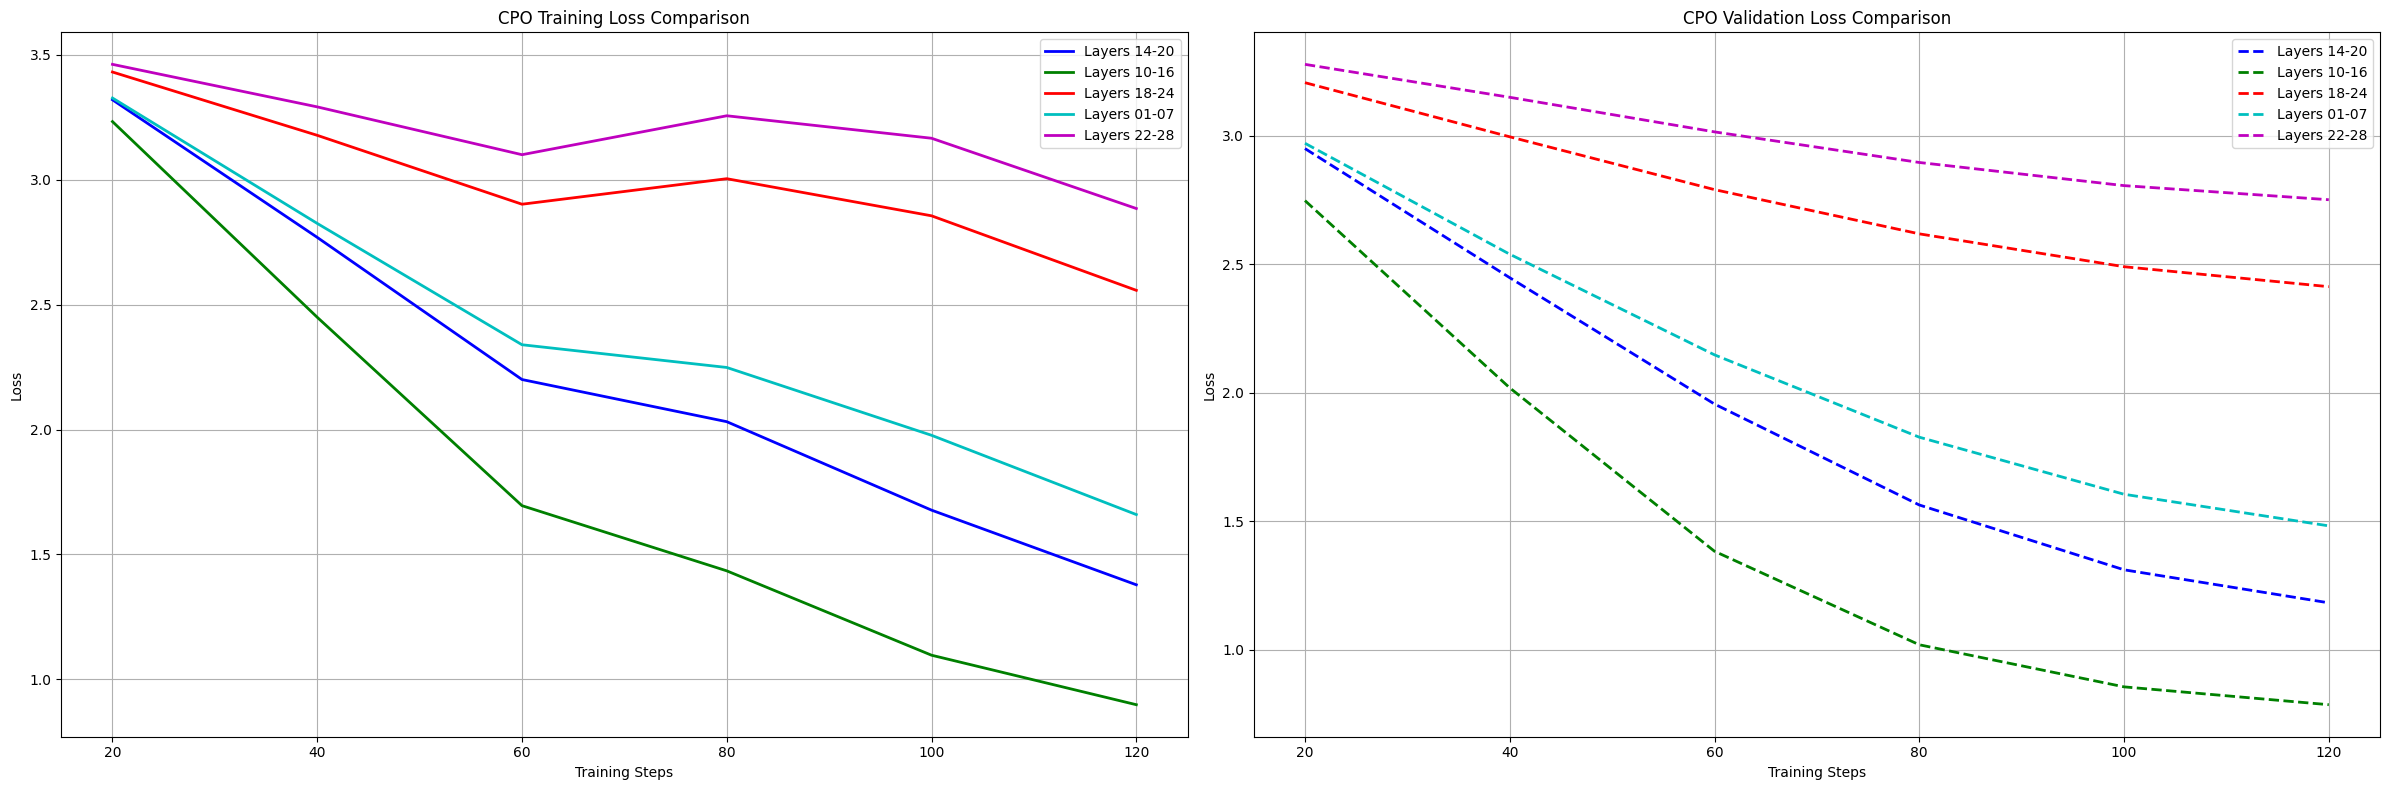

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(24, 8))
# Plot Training Loss
ax = axes[0]
for experiment in unique_experiments:
    subset = df_plot[(df_plot['Experiment'] == experiment) & (df_plot['Type'] == 'Training')]
    subset = subset.sort_values('Step')
    color = experiment_color_map.get(experiment, 'k')
    if not subset.empty:
        ax.plot(subset['Step'], subset['Loss'], label=experiment, color=color, linewidth=2)

ax.set_title('CPO Training Loss Comparison')
ax.set_xlabel('Training Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Plot Validation Loss
ax = axes[1]
for experiment in unique_experiments:
    subset = df_plot[(df_plot['Experiment'] == experiment) & (df_plot['Type'] == 'Validation')]
    subset = subset.sort_values('Step')
    color = experiment_color_map.get(experiment, 'k')
    if not subset.empty:
        ax.plot(subset['Step'], subset['Loss'], label=experiment, color=color, linewidth=2, linestyle='--')

ax.set_title('CPO Validation Loss Comparison')
ax.set_xlabel('Training Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

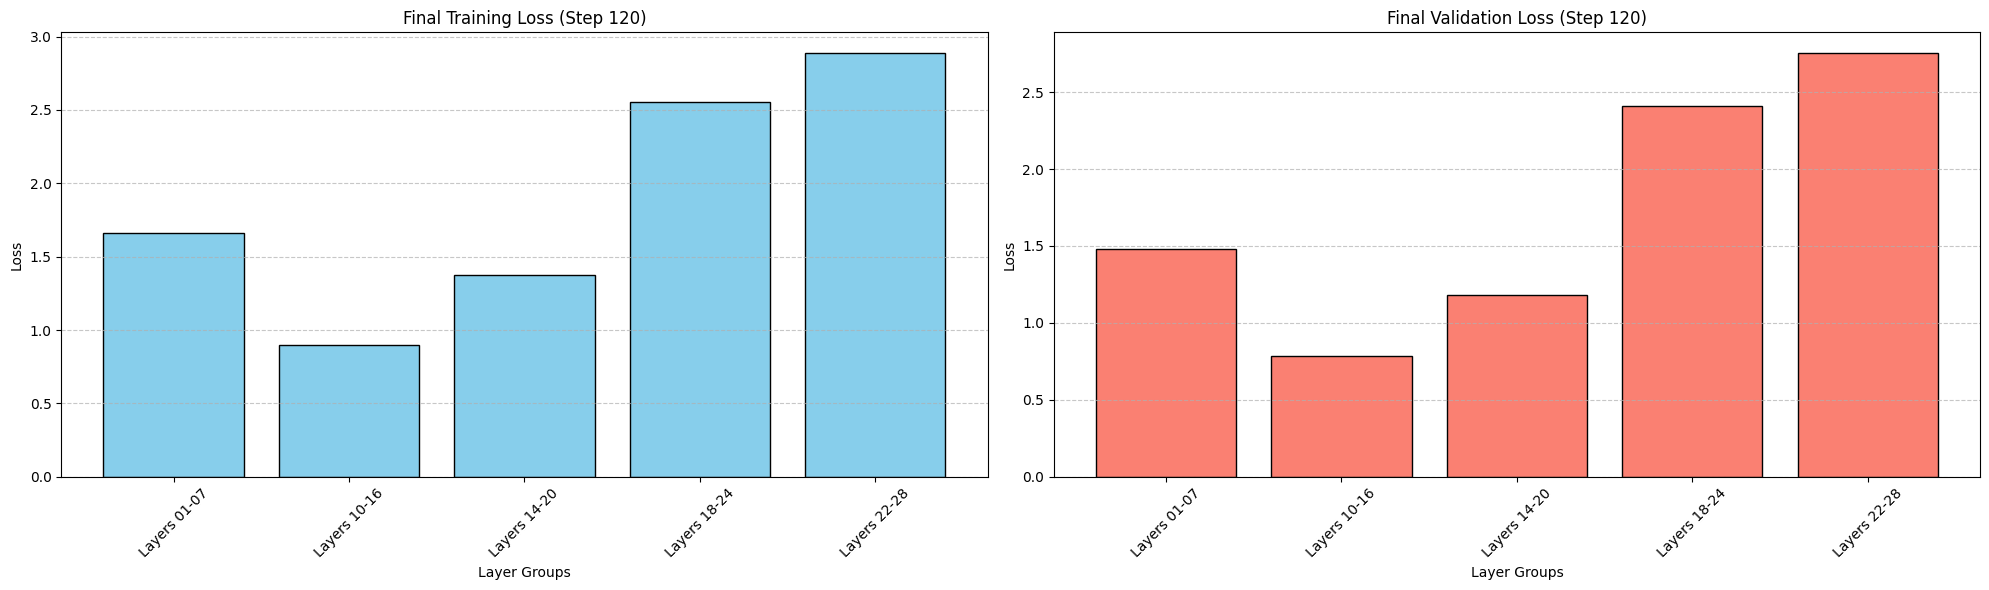

In [ ]:

last_step_data = df_plot.loc[df_plot.groupby(['Experiment', 'Type'])['Step'].idxmax()]

train_last = last_step_data[last_step_data['Type'] == 'Training'].sort_values('Experiment')
val_last = last_step_data[last_step_data['Type'] == 'Validation'].sort_values('Experiment')

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].bar(train_last['Experiment'], train_last['Loss'], color='skyblue', edgecolor='black')
axes[0].set_title(f'Final Training Loss (Step {train_last["Step"].iloc[0]})')
axes[0].set_xlabel('Layer Groups')
axes[0].set_ylabel('Loss')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].bar(val_last['Experiment'], val_last['Loss'], color='salmon', edgecolor='black')
axes[1].set_title(f'Final Validation Loss (Step {val_last["Step"].iloc[0]})')
axes[1].set_xlabel('Layer Groups')
axes[1].set_ylabel('Loss')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Results

As we can see, the middle layers 10-16 and 14-20 yeild better results than the first and last set of layers. What's interesting is that the early layers 1-7 yield better results than the last layers (18-24 and 22-28)

# Test Inference on CPO Layers

In [ ]:
df_test_cot.head()

,question,true_cot_steps,true_step_answers,true_final_answer
0,Janet’s ducks lay 16 eggs per day. She eats th...,[Step 1: Janet sells 16 - 3 - 4 = 9 duck eggs ...,"[9.0, 18.0, 18.0]",18.0
1,A robe takes 2 bolts of blue fiber and half th...,"[Step 1: It takes 2/2=1 bolt of white fiber, S...","[1.0, 3.0, 3.0]",3.0
2,Josh decides to try flipping a house. He buys...,[Step 1: The cost of the house and repairs cam...,"[130000.0, 120000.0, 200000.0, 70000.0, 70000.0]",70000.0
3,James decides to run 3 sprints 3 times a week....,"[Step 1: He sprints 3*3=9 times, Step 2: So he...","[9.0, 540.0, 540.0]",540.0
4,"Every day, Wendi feeds each of her chickens th...",[Step 1: If each chicken eats 3 cups of feed p...,"[60.0, 20.0, 20.0]",20.0


In [ ]:
df_test_cot.shape

(1319, 4)

In [ ]:
from tqdm.notebook import tqdm
import torch
import pandas as pd

def cpo_inference(model_to_run, df, batch_size=4, num_responses=1):
  results = []
  tokenizer.padding_side = "left"
  questions = df['question'].tolist()
  true_final_answers = df['true_final_answer'].tolist()
  true_cot_steps = df['true_cot_steps'].tolist()
  true_step_answers = df['true_step_answers'].tolist()

  for i in tqdm(range(0, len(questions), batch_size), desc="Processing Batches"):

    batch_questions = questions[i : i + batch_size]

    batch_prompts = [generate_full_prompt(q) for q in batch_questions]

    inputs = tokenizer(
        batch_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model_to_run.device)

    prompt_length = inputs['input_ids'].shape[1]

    with torch.no_grad():
      outputs = model_to_run.generate(
          **inputs,
          max_new_tokens=300,
          do_sample=True,
          temperature=1.0,
          pad_token_id=tokenizer.pad_token_id,
          num_return_sequences=num_responses
      )

    generated_tokens = outputs[:, prompt_length:]

    generated_texts = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

    for j, question in enumerate(batch_questions):
        start_idx = j * num_responses # FIXED: Removed 'i +' as generated_texts is local to the batch
        end_idx = start_idx + num_responses
        responses = generated_texts[start_idx : end_idx]

        true_cot_step = true_cot_steps[i + j]
        true_step_answer = true_step_answers[i + j]
        true_final_answer = true_final_answers[i + j]

        for response in responses:

          response = response.split('Question')[0].strip()

          generated_steps, generated_step_answers, generated_final_answer = get_step_data(response)

          results.append({
            'index': i + j + 1,
            'question': question,
            'true_cot_steps': true_cot_step,
            'true_step_answers': true_step_answer,
            'true_final_answer': true_final_answer,
            'generated_response': response,
            'generated_step_answers': generated_step_answers,
            'generated_cot_steps': generated_steps,
            'generated_final_answer': generated_final_answer,
            'is_correct': generated_final_answer == true_final_answer
          })

  return pd.DataFrame(results)

### Test inference on Layer CPO

In [ ]:
%%script true

import gc
from peft import PeftModel

# List of all adapter configurations
adapter_configs = [
    ("Layers 14-20", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-14-20"),
    ("Layers 10-16", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-10-16"),
    ("Layers 18-24", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-18-24"),
    ("Layers 01-07", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-01-07"),
    ("Layers 22-28", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-22-28"),
]

for name, adapter_path in adapter_configs:
    print(f"\n{'='*10} Processing {name} {'='*10}")

    if 'model_cpo' in globals(): del model_cpo
    if 'base_model' in globals(): del base_model
    torch.cuda.empty_cache()
    gc.collect()

    print(f"Loading base model: {MODEL_ID}")
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map=DEVICE_MAP,
        trust_remote_code=True
    )

    print(f"Loading LoRA adapter from: {adapter_path}")
    try:
        model_cpo = PeftModel.from_pretrained(base_model, adapter_path)
    except Exception as e:
        print(f"Failed to load adapter {name} at {adapter_path}: {e}")
        continue

    batch_size = 48
    print(f"Running inference for {name} on test set...")
    results_df = cpo_inference(model_cpo, df_test_cot, batch_size=batch_size)

    file_name = adapter_path.split('/')[-1] # e.g., qwen2.5-7b-cpo-14-20
    save_path = f'/content/drive/MyDrive/CS494/Project/cpo_inference_test/{file_name}.csv'
    results_df.to_csv(save_path, index=False)
    print(f"Saved results to {save_path}")

    print(f"Completed {name}.")

print("\nAll experiments completed successfully.")

### Test Inference on Base Model

In [ ]:
%%script true

if 'model_cpo' in globals(): del model_cpo
if 'model' in globals(): del model
if 'base_model' in globals(): del base_model
torch.cuda.empty_cache()
gc.collect()

print(f"Loading base model: {MODEL_ID}")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)

batch_size = 48
print(f"Running inference for base_model on test set...")
results_df = cpo_inference(base_model, df_test_cot, batch_size=batch_size)

file_name = 'qwen2.5-7b_base'
save_path = f'/content/drive/MyDrive/CS494/Project/cpo_inference_test/{file_name}.csv'
results_df.to_csv(save_path, index=False)
print(f"Saved results to {save_path}")

### Plot test Inference Results

In [ ]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict

def clean_cot_steps(cot_steps: list[str]):

  new_steps = []

  for step in cot_steps:
   step = step.strip()
   if step.startswith('Final'):
     new_steps.append(step)
     return new_steps
   new_steps.append(step)
  return new_steps

import ast

def get_results(csv_file_path: str):

  df = pd.read_csv(csv_file_path)

  new_generated_checking = []

  for index, row in df.iterrows():
    cot_steps = ast.literal_eval(row['generated_cot_steps'])
    clean_steps = clean_cot_steps(cot_steps)
    generated_final_answer = extract_last_number_from_text('\n'.join(clean_steps))
    new_generated_checking.append({
        'generated_final_answer': generated_final_answer,
        'generated_cot_steps': clean_steps,
        'is_correct': generated_final_answer == row['true_final_answer']
    })

  inference_df = pd.DataFrame(new_generated_checking)
  counts = inference_df['is_correct'].value_counts()

  return inference_df, counts.get(True, 0) / counts.sum()

def plot_accuracies(accuracies: Dict):
  accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model Range', 'Accuracy'])

  # Create the bar plot
  plt.figure(figsize=(10, 6))
  sns.barplot(x='Model Range', y='Accuracy', data=accuracy_df, palette='viridis')
  plt.title('Accuracy of Models fine-tuned on specific layers')
  plt.xlabel('Model Layers')
  plt.ylabel('Accuracy')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  minimum = accuracy_df['Accuracy'].min()
  maximum = accuracy_df['Accuracy'].max()
  plt.ylim(minimum - 0.05, maximum + 0.05) # Set y-axis limits to highlight differences

  for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.005, f"{row['Accuracy']:.3f}", color='black', ha="center")

  plt.show()

def plot_comparison_accuracies(train_accs: Dict, test_accs: Dict):
    # Prepare data for plotting
    data = []
    for layer_range, acc in train_accs.items():
        data.append({'Model Range': layer_range, 'Accuracy': acc, 'Type': 'Train Accuracy'})
    for layer_range, acc in test_accs.items():
        data.append({'Model Range': layer_range, 'Accuracy': acc, 'Type': 'Test Accuracy'})

    comparison_df = pd.DataFrame(data)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Model Range', y='Accuracy', hue='Type', data=comparison_df, palette='deep')
    plt.title('Train vs. Test Accuracy for Different CPO Layers')
    plt.xlabel('Model Layers')
    plt.ylabel('Accuracy')
    plt.ylim(0.7, 0.88) # Adjust y-axis for better visibility of differences
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Accuracy Type')

    for container in plt.gca().containers:
        plt.bar_label(container, fmt='%.3f', label_type='edge', padding=3)

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-2597394549.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model Range', y='Accuracy', data=accuracy_df, palette='viridis')


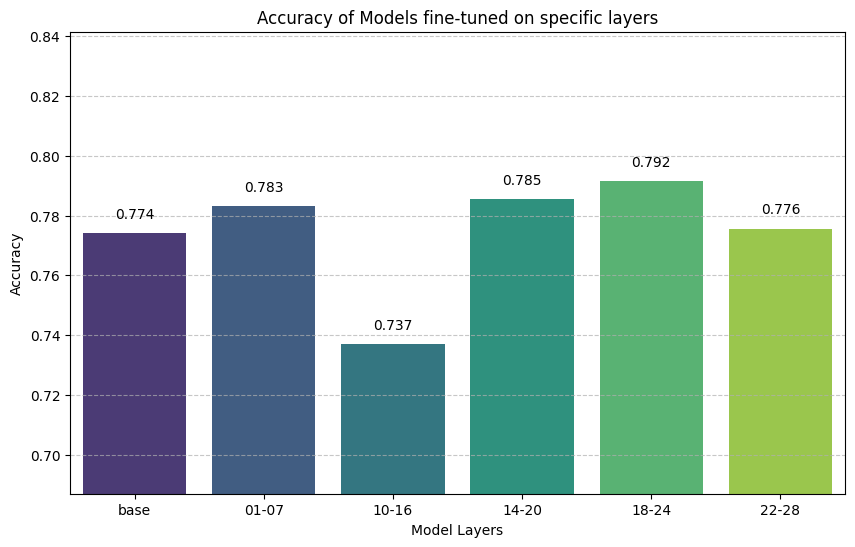

In [ ]:
inf_test_base_df, acc_test_base = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_test/qwen2.5-7b_base.csv')
inf_test_14_20_df, acc_test_14_20 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_test/qwen2.5-7b-cpo-14-20.csv')
inf_test_10_16_df, acc_test_10_16 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_test/qwen2.5-7b-cpo-10-16.csv')
inf_test_18_24_df, acc_test_18_24 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_test/qwen2.5-7b-cpo-18-24.csv')
inf_test_01_07_df, acc_test_01_07 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_test/qwen2.5-7b-cpo-01-07.csv')
inf_test_22_28_df, acc_test_22_28 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_test/qwen2.5-7b-cpo-22-28.csv')

test_accuracies = {
    'base': acc_test_base,
    '01-07': acc_test_01_07,
    '10-16': acc_test_10_16,
    '14-20': acc_test_14_20,
    '18-24': acc_test_18_24,
    '22-28': acc_test_22_28
}

plot_accuracies(test_accuracies)


## Run Train Inference

### Train Inference on CPO Layers

In [ ]:
%%script true

import gc
from peft import PeftModel

adapter_configs = [
    ("Layers 14-20", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-14-20"),
    ("Layers 10-16", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-10-16"),
    ("Layers 18-24", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-18-24"),
    ("Layers 01-07", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-01-07"),
    ("Layers 22-28", "/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-22-28"),
]

for name, adapter_path in adapter_configs:
    print(f"\n{'='*10} Processing {name} {'='*10}")

    if 'model_cpo' in globals(): del model_cpo
    if 'base_model' in globals(): del base_model
    torch.cuda.empty_cache()
    gc.collect()

    print(f"Loading base model: {MODEL_ID}")
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map=DEVICE_MAP,
        trust_remote_code=True
    )

    print(f"Loading LoRA adapter from: {adapter_path}")
    try:
        model_cpo = PeftModel.from_pretrained(base_model, adapter_path)
    except Exception as e:
        print(f"Failed to load adapter {name} at {adapter_path}: {e}")
        continue

    batch_size = 250
    print(f"Running inference for {name} on test set...")
    results_df = cpo_inference(model_cpo, df_train_cot, batch_size=batch_size)

    file_name = adapter_path.split('/')[-1] # e.g., qwen2.5-7b-cpo-14-20
    save_path = f'/content/drive/MyDrive/CS494/Project/cpo_inference_train/{file_name}.csv'
    results_df.to_csv(save_path, index=False)
    print(f"Saved results to {save_path}")

    print(f"Completed {name}.")

print("\nAll experiments completed successfully.")

### Train Inference on Base Layers

In [ ]:
%%script true

if 'model_cpo' in globals(): del model_cpo
if 'model' in globals(): del model
if 'base_model' in globals(): del base_model
torch.cuda.empty_cache()
gc.collect()

print(f"Loading base model: {MODEL_ID}")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)

batch_size = 250
print(f"Running inference for base_model on train set...")
results_df = cpo_inference(base_model, df_train_cot, batch_size=batch_size)

file_name = 'qwen2.5-7b_base'
save_path = f'/content/drive/MyDrive/CS494/Project/cpo_inference_train/{file_name}.csv'
results_df.to_csv(save_path, index=False)
print(f"Saved results to {save_path}")

/tmp/ipython-input-2597394549.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model Range', y='Accuracy', data=accuracy_df, palette='viridis')


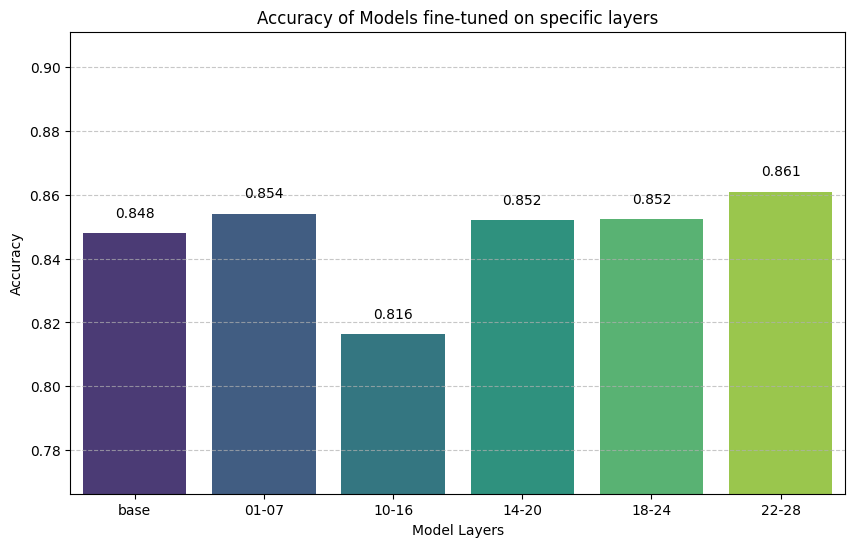

In [ ]:
inf_train_base_df, acc_train_base = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b_base.csv')
inf_train_14_20_df, acc_train_14_20 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b-cpo-14-20.csv')
inf_train_10_16_df, acc_train_10_16 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b-cpo-10-16.csv')
inf_train_18_24_df, acc_train_18_24 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b-cpo-18-24.csv')
inf_train_01_07_df, acc_train_01_07 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b-cpo-01-07.csv')
inf_train_22_28_df, acc_train_22_28 = get_results('/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b-cpo-22-28.csv')

train_accuracies = {
    'base': acc_train_base,
    '01-07': acc_train_01_07,
    '10-16': acc_train_10_16,
    '14-20': acc_train_14_20,
    '18-24': acc_train_18_24,
    '22-28': acc_train_22_28
}

plot_accuracies(train_accuracies)

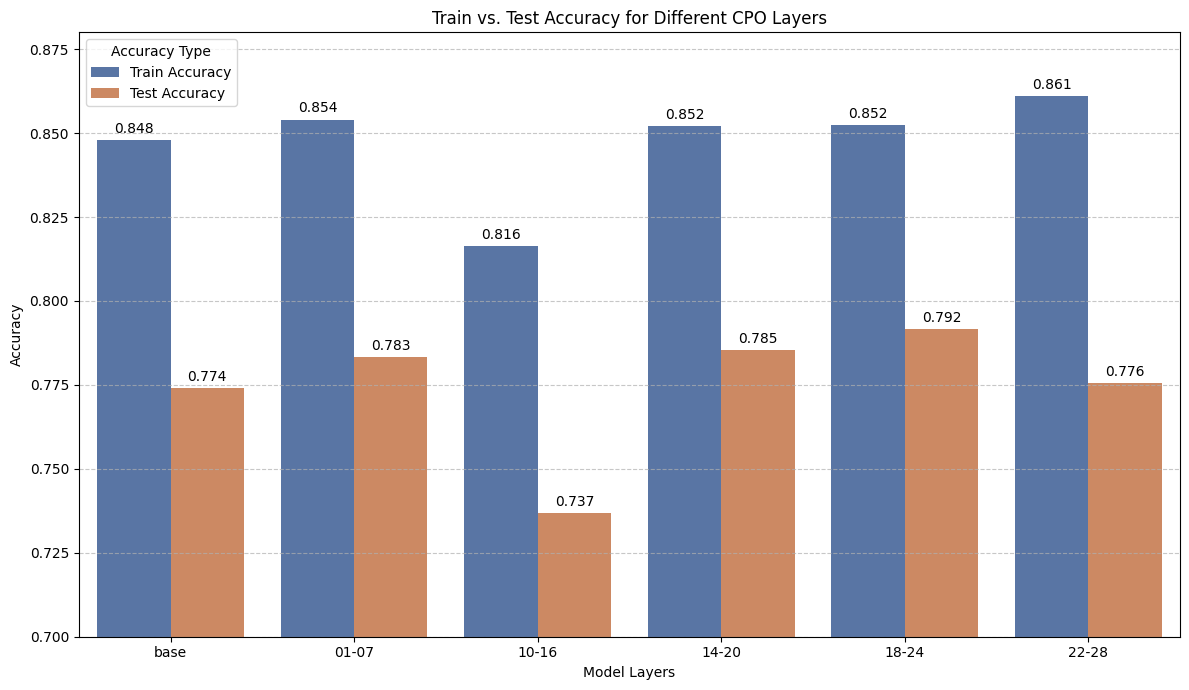

In [ ]:
plot_comparison_accuracies(train_accuracies, test_accuracies)

# Sparse AutoEncoders: Diagnosis and Feature Steering

* Phase 1: Setup & Training
  * Identify Placement: Target the MLP output of the 24th layer (specifically after the activation function like GELU). This location captures middle-to-late stage reasoning.
  * Collect Data:
    * Load your base transformer.
    * Attach a hook to the 24th layer's MLP output.
    * Run a relevant dataset (e.g., GSM8K) through the model and save the activations.
  * Train the SAE:
    * Architecture: Encoder → ReLU → Decoder.
    * Objective: Minimize reconstruction loss (MSE) while enforcing sparsity (L1 penalty) on the latent features.
* Phase 2: Analysis & Interpretation
  * Interpret Features: Analyze the trained SAE to find specific features that correlate with model behavior.
  * Identify Targets: Look for specific features that represent "correct reasoning" or "errors" to target for intervention.
* Phase 3: Feature Steering (Intervention)
  * Hook the Model: Implement a forward hook at the 24th layer during inference.
  * Encode: Pass the live layer activations into the SAE Encoder to get the sparse features.
  * Modify: Manually amplify "correction features" or suppress "error features" in the latent space.
  * Decode: Pass the modified features through the SAE Decoder to reconstruct the activations.
  * Replace: Overwrite the original model activations with your modified reconstruction and let the forward pass continue.

### Pre-defined Functions

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM
import gc

In [ ]:
class SAE(nn.Module):
    def __init__(self, d_model: int, d_sae: int, sparsity_lambda: float = 1e-4):
        super().__init__()
        self.encoder = nn.Linear(d_model, d_sae)
        self.decoder = nn.Linear(d_sae, d_model)
        self.relu = nn.ReLU()
        self.sparsity_lambda = sparsity_lambda
        # Initialize decoder weights to have unit norm, as is common in SAE literature
        nn.init.kaiming_uniform_(self.encoder.weight)
        self.decoder.weight.data = self.encoder.weight.data.T.clone()

    def forward(self, x: torch.Tensor):
        # Encode
        hidden_activations = self.encoder(x)
        latent = self.relu(hidden_activations)

        # Decode
        reconstruction = self.decoder(latent)
        return reconstruction, latent

    def get_reconstruction_loss(self, original_input: torch.Tensor, reconstruction: torch.Tensor):
        return nn.functional.mse_loss(reconstruction, original_input)

    def get_sparsity_loss(self, latent_activations: torch.Tensor):
        # L1 norm on the latent activations to encourage sparsity
        return torch.norm(latent_activations, p=1, dim=-1).mean()

    def total_loss(self, original_input: torch.Tensor, reconstruction: torch.Tensor, latent_activations: torch.Tensor):
        recon_loss = self.get_reconstruction_loss(original_input, reconstruction)
        sparsity_loss = self.get_sparsity_loss(latent_activations)
        return recon_loss + self.sparsity_lambda * sparsity_loss, recon_loss, sparsity_loss

print("SAE class defined.")

SAE class defined.


In [ ]:
class ActivationDataset(Dataset):
    def __init__(self, activations_tensor: torch.Tensor):
        self.activations = activations_tensor

    def __len__(self):
        return len(self.activations)

    def __getitem__(self, idx):
        return self.activations[idx]

print('ActivationDataset class defined.')

ActivationDataset class defined.


In [ ]:
# Clear previous model if exists to ensure a fresh base model load
if 'model' in globals():
    del model
if 'base_model' in globals():
    del base_model
torch.cuda.empty_cache()
gc.collect()

5057

In [ ]:
def prompt_with_teacher_forcing(question, cot_steps):
    # Start with the standard prompt
    prompt = f'''{prefix}

Question: {question}
Solution:
'''

    # TEACHER FORCING: Append the actual reasoning steps to the input string
    # We join them exactly as they appear in the training data
    # Ensure you add newlines if your tokenizer expects them between steps
    ground_truth_reasoning = "\n".join(cot_steps)

    full_text = prompt + ground_truth_reasoning
    return full_text

In [ ]:
def get_all_activations(model, layer_to_hook, activations_save_path, num_rows: int=500):

    print(f"Loading base model: {MODEL_ID} for activation collection...")
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map=DEVICE_MAP,
        trust_remote_code=True
    )
    base_model.eval()

    captured_activations = []

    def hook_fn(module, input, output):
        if isinstance(output, tuple):
            activations = output[0]
        else:
            activations = output
        captured_activations.append(activations.cpu().detach().view(-1, d_model))

    target_module = base_model.model.layers[LAYER_TO_HOOK].mlp.down_proj
    handle = target_module.register_forward_hook(hook_fn)

    print(f"Collecting activations from layer {LAYER_TO_HOOK} ({LAYER_TO_HOOK+1}th layer) MLP output...")

    activation_collection_df = df_train_cot.head(num_rows)

    tokenizer.padding_side = "left"

    for i in tqdm(range(len(activation_collection_df)), desc="Collecting Activations"):
        question = activation_collection_df.iloc[i]['question']
        true_cot_steps = activation_collection_df.iloc[i]['true_cot_steps']
        full_prompt = prompt_with_teacher_forcing(question, true_cot_steps)

        inputs = tokenizer(
            full_prompt,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(base_model.device)

        with torch.no_grad():
            _ = base_model(**inputs)

    handle.remove()

    all_activations = torch.cat(captured_activations, dim=0)
    print(f"Collected {all_activations.shape[0]} activations of dimension {all_activations.shape[1]}.")

    torch.save(all_activations, activations_save_path)
    print(f"Activations saved to {activations_save_path}")

    return all_activations

In [ ]:
def cleanup(base_model):
    del base_model
    torch.cuda.empty_cache()
    gc.collect()
    print("Base model unloaded and GPU memory cleared.")

def load_activations_from_file(file_path):
    if os.path.exists(file_path):
      print(f"Loading activations from {file_path}...")
      all_activations = torch.load(file_path)
      print(f"Successfully loaded {all_activations.shape[0]} activations of dimension {all_activations.shape[1]}.")
    else:
      print(f"Activations file not found at {file_path}.")
      print("Please run the activation collection cell (above) to generate and save the activations first.")
      all_activations = None
    return all_activations

In [ ]:
def train_sae(all_activations, d_model:int, d_sae: int, num_epochs_sae=20, batch_size=256, lr=1e-3, sparsity_lambda=1e-2, device='cuda'):

    sae_dataset = ActivationDataset(all_activations)
    sae_dataloader = DataLoader(sae_dataset, batch_size=batch_size, shuffle=True)

    # Instantiate SAE model
    sae_model = SAE(d_model=d_model, d_sae=d_sae, sparsity_lambda=sparsity_lambda).to(device) # Ensure SAE is on the same device
    optimizer = torch.optim.Adam(sae_model.parameters(), lr=lr)

    # --- SAE Training Loop ---

    print("Starting SAE training...")

    history = {'total_loss': [], 'recon_loss': [], 'sparsity_loss': []}

    for epoch in tqdm(range(num_epochs_sae), desc="SAE Epochs"):
        total_loss = 0.0
        total_recon_loss = 0.0
        total_sparsity_loss = 0.0
        inner_prog_bar = tqdm(total=len(sae_dataloader), desc=f"Epoch {epoch+1}", leave=False)
        for batch_idx, activations_batch in enumerate(sae_dataloader):
            inner_prog_bar.update(1)
            # Ensure activations_batch is moved to the correct device and converted to float32
            activations_batch = activations_batch.to(sae_model.encoder.weight.device).float()

            optimizer.zero_grad()
            reconstruction, latent = sae_model(activations_batch)
            loss, recon_loss, sparsity_loss = sae_model.total_loss(activations_batch, reconstruction, latent)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_sparsity_loss += sparsity_loss.item()

            inner_prog_bar.set_postfix(loss=loss.item())
        inner_prog_bar.close()

        avg_loss = total_loss / len(sae_dataloader)
        avg_recon_loss = total_recon_loss / len(sae_dataloader)
        avg_sparsity_loss = total_sparsity_loss / len(sae_dataloader)

        history['total_loss'].append(avg_loss)
        history['recon_loss'].append(avg_recon_loss)
        history['sparsity_loss'].append(avg_sparsity_loss)

        print(f"Epoch {epoch+1} Complete: Total Loss = {avg_loss:.4f}, Recon Loss = {avg_recon_loss:.4f}, Sparsity Loss = {avg_sparsity_loss:.4f}")

    print("SAE Training complete.")

    return sae_model, history

In [ ]:
import matplotlib.pyplot as plt
import json
import os

def save_history_to_json(history, file_path):

    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    serializable_history = {}
    for key, value in history.items():
        serializable_history[key] = [item.tolist() if isinstance(item, torch.Tensor) else item for item in value]
    with open(file_path, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"SAE training history saved to {file_path}")

def read_history_from_json(file_path) -> dict :
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            loaded_history = json.load(f)
        history = loaded_history
        return history
    print(f"Error: History file not found at {SAE_HISTORY_SAVE_PATH}")
    return {}

def plot_losses(history, layer):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 row, 3 columns
    fig.suptitle(f'SAE Losses for Layer {layer}', fontsize=16)

    # Plot Total Loss
    axes[0].plot(history['total_loss'], label='Total Loss', color='blue')
    axes[0].set_title('SAE Total Loss Over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot Reconstruction Loss
    axes[1].plot(history['recon_loss'], label='Reconstruction Loss', color='green')
    axes[1].set_title('SAE Reconstruction Loss Over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    # Plot Sparsity Loss
    axes[2].plot(history['sparsity_loss'], label='Sparsity Loss', color='red')
    axes[2].set_title('SAE Sparsity Loss Over Epochs')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

In [ ]:
import ast
import re

def extract_numbers_from_string(text: str) -> list[float]:
    """
    Extracts all positive numbers (integers or decimals) from a string
    and returns them as a list of floats.

    Args:
        text (str): The input string.

    Returns:
        list[float]: A list of extracted numbers as floats.
    """
    # Regex to find integers or decimals. It captures:
    # 1. One or more digits (for integers)
    # 2. Or, one or more digits followed by a dot and one or more digits (for decimals)
    # It explicitly looks for positive numbers, as per the guarantee.
    numbers = re.findall(r'\b\d+\.?\d*\b', text)
    return [float(num) for num in numbers if num.strip()]

def extract_till_final_answer(cot_steps: list[str]):

  cot_steps = ast.literal_eval(cot_steps)
  new_steps = []

  for step in cot_steps:
   step = step.strip()
   if step.startswith('Final'):
     new_steps.append(step)
     return new_steps
   new_steps.append(step)
  return new_steps

def df_for_sae(base_csv: str, cpo_csv: str):
  base_df = pd.read_csv(base_csv)
  cpo_df = pd.read_csv(cpo_csv)

  cpo_correct_list = []
  len = base_df.shape[0]
  for i in range(len):
    base_row = base_df.iloc[i]
    cpo_row = cpo_df.iloc[i]

    base_possible_answers = extract_numbers_from_string(base_row['generated_response'])
    cpo_possible_answers = extract_numbers_from_string(cpo_row['generated_response'])

    base_correct = base_row['true_final_answer'] in base_possible_answers
    cpo_correct = cpo_row['true_final_answer'] in cpo_possible_answers

    if cpo_correct and not base_correct:
      base_cot_steps = extract_till_final_answer(base_row['generated_cot_steps'])
      cpo_cot_steps = extract_till_final_answer(cpo_row['generated_cot_steps'])
      base_final_answer = extract_last_number_from_text(base_row['generated_response'])
      cpo_final_answer = extract_last_number_from_text(cpo_row['generated_response'])

      cpo_correct_dict = {
        'question': base_row['question'],
        'true_cot_steps': base_row['true_cot_steps'],
        'true_step_answers': base_row['true_step_answers'],
        'true_final_answer': base_row['true_final_answer'],

        'base_response': base_row['generated_response'],
        'base_step_answers': base_row['generated_step_answers'],
        'base_cot_steps': base_cot_steps,
        'base_final_answer': base_final_answer,

        'cpo_response': cpo_row['generated_response'],
        'cpo_step_answers': cpo_row['generated_step_answers'],
        'cpo_cot_steps': cpo_cot_steps,
        'cpo_final_answer': cpo_final_answer,
      }

      cpo_correct_list.append(cpo_correct_dict)

  sae_df = pd.DataFrame(cpo_correct_list)
  return sae_df

## Phase 1: Training the SAE on base_model

### Configurations

In [ ]:
ACTIVATIONS_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/'
LAYER_TO_HOOK = 23 # the 24th layer
NUM_ROWS=500
d_model=3584
d_sae=28672

### a. Loading the Model and Setting SAE dimensions



In [ ]:
%%script true
print(f"Loading base model: {MODEL_ID} for activation collection...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)
base_model.eval()
device = base_model.device

d_model = base_model.config.hidden_size
d_sae = d_model * 8
d_model, d_sae

We're taking latent dimensions to 8 times the Transformer hidden size.

### b. Getting all the activations

In [ ]:
num_rows=500
path = os.path.join(ACTIVATIONS_SAVE_PATH, f'activations_{LAYER_TO_HOOK}_{num_rows}.pt')

In [ ]:
%%script true

all_activations = get_all_activations(base_model, LAYER_TO_HOOK, path, num_rows=NUM_ROWS)

In [ ]:
%%script true
cleanup(base_model)

In [ ]:
%%script true
all_activations = load_activations_from_file(path)
all_activations.shape

### c. Training the SAE Model based on activations

Always remember to **free the memory**.

#### How to set sparsity lambda?

1. Fixed Schedule: Decrease sparsity_lambda linearly or exponentially over epochs.

2. Adaptive Based on Sparsity Metric: Define a target sparsity (e.g., 1e-3, meaning 0.1% of features are active on average). At the end of each epoch:

    * Example Logic: if actual_sparsity < target_sparsity: sparsity_lambda *= factor_increase
    * Example Logic: if actual_sparsity > target_sparsity: sparsity_lambda *= factor_decrease


3. Adaptive Based on Reconstruction Loss vs. Sparsity Loss: If recon_loss is still very high but sparsity_loss is already very low, decrease sparsity_lambda to allow for more feature activation.

#### Configuration 1:

* num_epochs = 20
* batch size = 256
* learning rate = 5e-5
* sparsity lambda = 1e-3

In [ ]:
SAE_MODEL_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config1/model.pth'
SAE_HISTORY_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config1/history.json'

In [ ]:
%%script true

if 'sae_model' in globals():
    del sae_model
    torch.cuda.empty_cache()
    gc.collect()

sae_model, history = train_sae(
    all_activations,
    d_model=d_model,
    d_sae=d_sae,
    num_epochs_sae=20,
    batch_size=256,
    lr=5e-5,
    sparsity_lambda=1e-3,
    device=device
)

os.makedirs(os.path.dirname(SAE_MODEL_SAVE_PATH), exist_ok=True)
torch.save(sae_model.state_dict(), SAE_MODEL_SAVE_PATH)
print("SAE model saved.")
save_history_to_json(history, SAE_HISTORY_SAVE_PATH)
print("SAE training history saved.")

Epoch 20 Complete: Total Loss = 0.4279, Recon Loss = 0.2652, Sparsity Loss = 162.6674

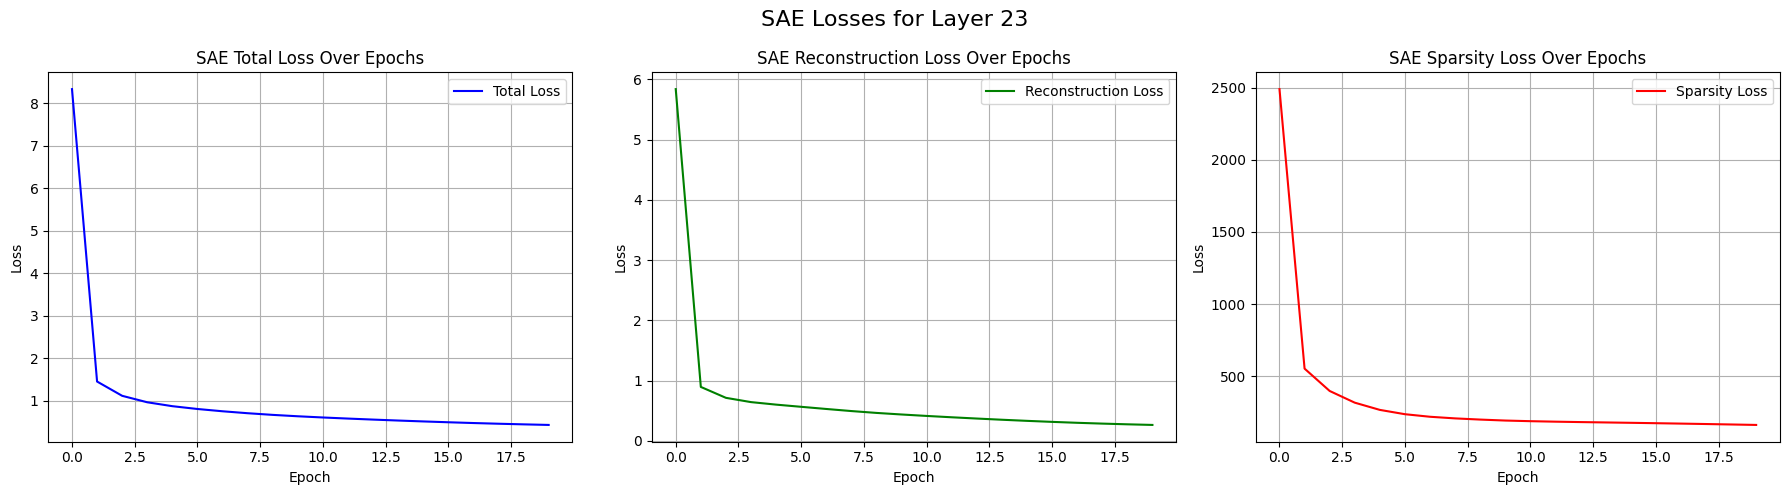

In [ ]:
history = read_history_from_json(SAE_HISTORY_SAVE_PATH)
plot_losses(history, LAYER_TO_HOOK)

#### Configuration 2:

* num_epochs = 20
* batch size = 256
* learning rate = 5e-5
* sparsity lambda = 5e-3

In [ ]:
SAE_MODEL_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config2/model.pth'
SAE_HISTORY_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config2/history.json'

In [ ]:
%%script true

if 'sae_model' in globals():
    del sae_model
    torch.cuda.empty_cache()
    gc.collect()

sae_model, history = train_sae(
    all_activations,
    d_model=d_model,
    d_sae=d_sae,
    num_epochs_sae=20,
    batch_size=256,
    lr=5e-5,
    sparsity_lambda=5e-3,
    device=device
)

os.makedirs(os.path.dirname(SAE_MODEL_SAVE_PATH), exist_ok=True)
torch.save(sae_model.state_dict(), SAE_MODEL_SAVE_PATH)
print("SAE model saved.")
save_history_to_json(history, SAE_HISTORY_SAVE_PATH)
print("SAE training history saved.")

Epoch 20 Complete: Total Loss = 1.0198, Recon Loss = 0.9206, Sparsity Loss = 19.8397

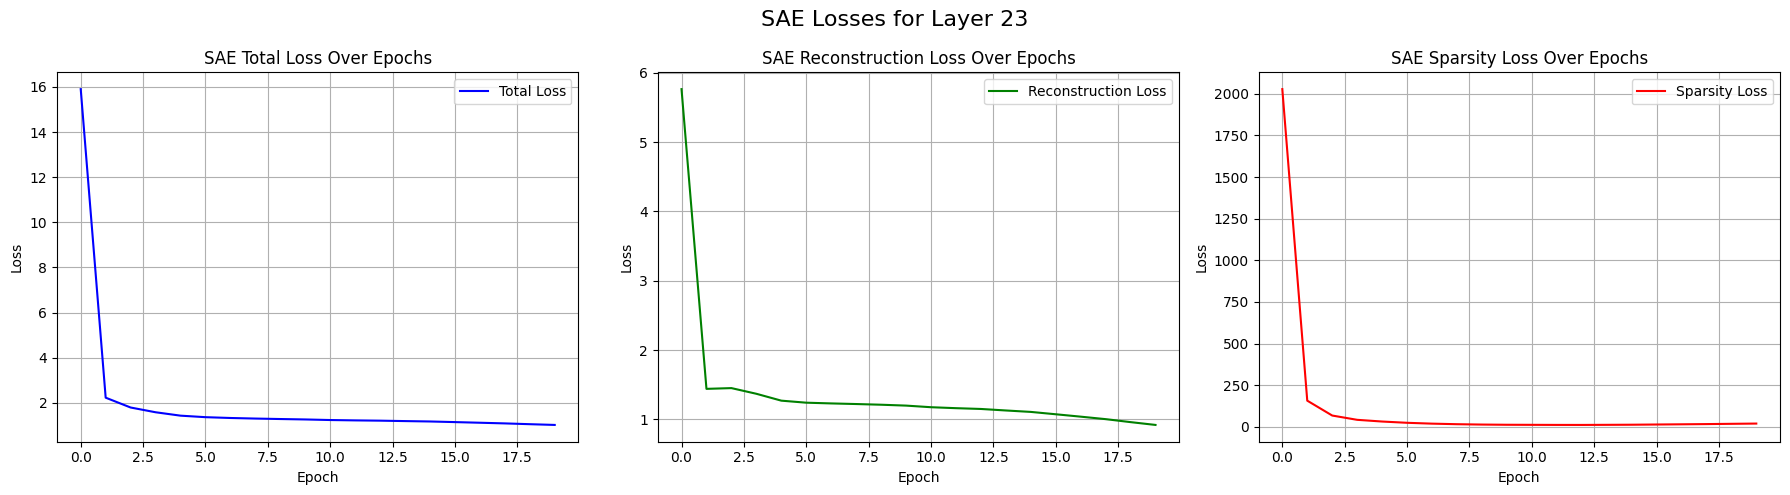

In [ ]:
history = read_history_from_json(SAE_HISTORY_SAVE_PATH)
plot_losses(history, LAYER_TO_HOOK)

#### Configuration 3:

* num_epochs = 20
* batch size = 256
* learning rate = 5e-5
* sparsity lambda = 3e-3

In [ ]:
SAE_MODEL_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config3/model.pth'
SAE_HISTORY_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config3/history.json'

In [ ]:
%%script true

if 'sae_model' in globals():
    del sae_model
    torch.cuda.empty_cache()
    gc.collect()

sae_model, history = train_sae(
    all_activations,
    d_model=d_model,
    d_sae=d_sae,
    num_epochs_sae=20,
    batch_size=256,
    lr=5e-5,
    sparsity_lambda=3e-3,
    device=device
)

os.makedirs(os.path.dirname(SAE_MODEL_SAVE_PATH), exist_ok=True)
torch.save(sae_model.state_dict(), SAE_MODEL_SAVE_PATH)
print("SAE model saved.")
save_history_to_json(history, SAE_HISTORY_SAVE_PATH)
print("SAE training history saved.")

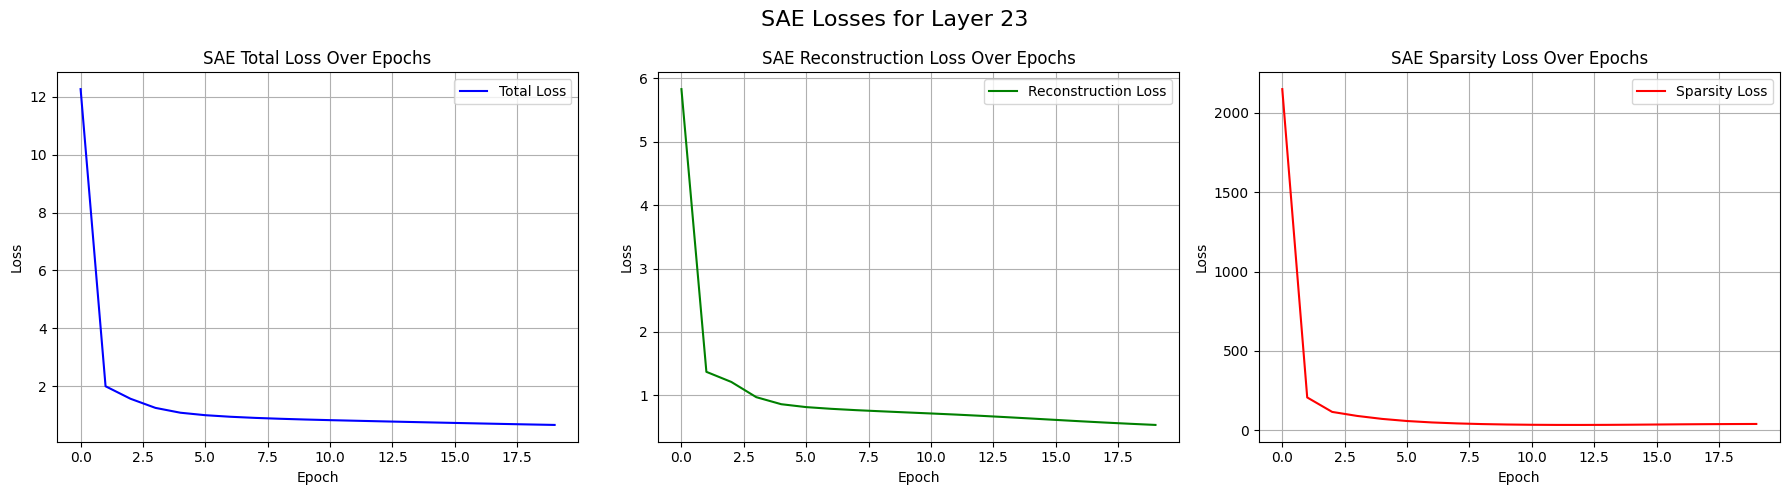

In [ ]:
history = read_history_from_json(SAE_HISTORY_SAVE_PATH)
plot_losses(history, LAYER_TO_HOOK)

## Phase 2: Check Activations Latent Space

In [ ]:
import gc
from peft import PeftModel

LAYER_TO_HOOK = 23 # the 24th layer
CPO_MODEL_PATH = '/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-18-24'

BASE_MODEL_ACTIVATIONS_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/base_model_activations_23_500.pt'
CPO_MODEL_ACTIVATIONS_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/cpo_model_activations_18-24_23_500.pt'
SAE_MODEL_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config3/model.pth'

d_model=3584
d_sae=28672
device='cuda'

BASE_LATENT_ACTIVATIONS_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/base_latent_activations_23_500.pt'
CPO_LATENT_ACTIVATIONS_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/cpo_latent_activations_18-24_23_500.pt'
os.makedirs(os.path.dirname(BASE_LATENT_ACTIVATIONS_SAVE_PATH), exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

save_dir = '/content/drive/MyDrive/CS494/Project/SAE/analysis_results/'
os.makedirs(save_dir, exist_ok=True)

Using device: cuda


### a. Collect activations again from model.

We are modifying this function again so that we can hook into the 24th layer (23 on 0-index) for both the Base model, as well as the CPO Model.

The hooking into the CPO Model works differently than the base model.

#### To get Layers in:

* In base model,
    
      target_module = model_instance.model.layers

* In CPO Model,

      target_module = model_instance.get_base_model().model.layers

In [ ]:
mismatch_df = df_for_sae(
    '/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b_base.csv',
    '/content/drive/MyDrive/CS494/Project/cpo_inference_train/qwen2.5-7b-cpo-18-24.csv'
)
mismatch_df.head()

,question,true_cot_steps,true_step_answers,true_final_answer,base_response,base_step_answers,base_cot_steps,base_final_answer,cpo_response,cpo_step_answers,cpo_cot_steps,cpo_final_answer
0,Lee mows one lawn and charges $33. Last week h...,"['Step 1: 33 * 16 = $528', 'Step 2: 3 * 10 = $...","[528.0, 30.0, 558.0, 558.0, 558.0]",558.0,Step 1: Calculate the earnings from mowing law...,"[16.0, 10.0, 10.0, 10.0]",[Step 1: Calculate the earnings from mowing la...,10.0,Step 1: Calculate the total earnings from mowi...,"[528.0, 30.0, 558.0, 558.0, 1.0, 2.0, 72.0, 1....",[Step 1: Calculate the total earnings from mow...,558.0
1,Alice has 20 quarters. She wants to exchange t...,['Step 1: A quarter is worth five nickels beca...,"[5.0, 100.0, 20.0, 80.0, 60.0, 4.0, 64.0, 64.0]",64.0,Step 1: Calculate the total amount of money Al...,"[25.0, 100.0, 80.0, 5.0, 5.0]",[Step 1: Calculate the total amount of money A...,5.0,Step 1: Calculate the number of nickels Alice ...,"[100.0, 20.0, 60.0, 4.0, 64.0, 64.0, 20.0, 2.0]",[Step 1: Calculate the number of nickels Alice...,2.0
2,Henry took 9 pills a day for 14 days. Of these...,"['Step 1: There were 9-4 = 5 other pills', 'St...","[5.0, 7.0, 35.0, 6.0, 41.0, 41.0]",41.0,Step 1: Calculate the cost of the first type o...,"[50.0, 0.0, 56.0, 98.0, 50.0, 0.0, 0.0, 0.0, 5...",[Step 1: Calculate the cost of the first type ...,56.0,Step 1: Calculate the cost of the first type o...,"[0.0, 0.0, 5.0, 0.0, 0.0, 0.0, 1.0, 2.0, 3.0, ...",[Step 1: Calculate the cost of the first type ...,4.0
3,A young girl pours 23 blue beads and 16 yellow...,['Step 1: There are 23+16=39 beads in the bowl...,"[39.0, 13.0, 3.0, 10.0, 10.0]",10.0,Step 1: Calculate the total number of beads in...,"[39.0, 18.0, 7.0, 7.0]",[Step 1: Calculate the total number of beads i...,7.0,Step 1: The girl had 23 + 16 = 39 beads in tot...,"[39.0, 13.0, 3.0, 10.0, 10.0]",[Step 1: The girl had 23 + 16 = 39 beads in to...,10.0
4,"In a section of the forest, there are 100 weas...",['Step 1: 3 foxes catch 4 weasels each every w...,"[12.0, 36.0, 6.0, 18.0, 64.0, 32.0, 96.0, 96.0]",96.0,Step 1: Calculate the total number of weasels ...,"[12.0, 6.0, 36.0, 18.0, 64.0, 32.0, 7.0]",[Step 1: Calculate the total number of weasels...,7.0,Step 1: First find the total number of rabbits...,"[18.0, 54.0, 96.0, 96.0, 3.0, 64.0, 32.0, 6.0]",[Step 1: First find the total number of rabbit...,6.0


In [ ]:
mismatch_df.shape

(419, 12)

In [ ]:
def collect_activations_from_model_for_sae_latent(model_instance, layer_to_hook, activations_save_path, cpo=False):

    print(f"Collecting activations from model on layer {layer_to_hook}...")
    model_instance.eval() # Ensure the model is in evaluation mode

    captured_activations = []

    def hook_fn(module, input, output):
        if isinstance(output, tuple):
            activations = output[0]
        else:
            activations = output
        # Ensure d_model is defined or passed if not a global
        captured_activations.append(activations.cpu().detach().view(-1, d_model))

    print('cpo', cpo)

    if not cpo:
      target_module = model_instance.model.layers[layer_to_hook].mlp.down_proj
    else:
      target_module = model_instance.get_base_model().model.layers[layer_to_hook].mlp.down_proj

    handle = target_module.register_forward_hook(hook_fn)

    print(f"Collecting activations from layer {layer_to_hook} ({layer_to_hook+1}th layer) MLP output...")

    tokenizer.padding_side = "left"

    for i in tqdm(range(len(mismatch_df)), desc="Collecting Activations"):
        question = mismatch_df.iloc[i]['question']
        if not cpo:
          cot_steps = mismatch_df.iloc[i]['base_cot_steps']
        else:
          cot_steps = mismatch_df.iloc[i]['cpo_cot_steps']
        full_prompt = prompt_with_teacher_forcing(question, cot_steps)

        inputs = tokenizer(
            full_prompt,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(model_instance.device)

        with torch.no_grad():
            _ = model_instance(**inputs)

    handle.remove()

    all_activations = torch.cat(captured_activations, dim=0)
    print(f"Collected {all_activations.shape[0]} activations of dimension {all_activations.shape[1]}.")

    torch.save(all_activations, activations_save_path)
    print(f"Activations saved to {activations_save_path}")

    return all_activations

#### Getting activations for Base Model.

In [ ]:
%%script true

if 'base_model' in globals():
    del base_model
torch.cuda.empty_cache()
gc.collect()

print(f"Loading base model: {MODEL_ID} for activation collection...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)
base_model.eval()

base_model_activations = collect_activations_from_model_for_sae_latent(
    model_instance=base_model,
    layer_to_hook=LAYER_TO_HOOK,
    activations_save_path=BASE_MODEL_ACTIVATIONS_PATH,
    cpo=False
)

cleanup(base_model)

#### Getting activations for CPO Model

Configurations:
CPO on layers 18-24

In [ ]:
%%script true

if 'base_model' in globals():
    del base_model
torch.cuda.empty_cache()
gc.collect()

print(f"Loading base model: {MODEL_ID}")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)

print(f"Loading LoRA adapter from: {CPO_MODEL_PATH}")
model_cpo = PeftModel.from_pretrained(base_model, CPO_MODEL_PATH)
model_cpo.eval()

cpo_model_activations = collect_activations_from_model_for_sae_latent(
    model_instance=model_cpo,
    layer_to_hook=LAYER_TO_HOOK,
    activations_save_path=CPO_MODEL_ACTIVATIONS_PATH,
    cpo=True
)

cleanup(model_cpo)

#### Hard-coding the Model and SAE dimensions

Previously, we were:
1. Loading Base Model
2. Checking the dimensions `d_model` of the Down Projection layer.
3. Setting SAE Latent dimensions `d_sae = d_model * 8`.

Now, we are hardcoding it, because:
1. The steps below are extremely memory intensive.
2. Deleting the model does not guarantee GPU memory will be free.
3. Even on an A100, some cells were running out of memory.
4. We use the same model throughout the notebook. It's dimensions are not changing. And neither are the SAEs.

### b. Running the activations through the SAE to get Latent Activations in SAEs.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Loading SAE model from: {SAE_MODEL_SAVE_PATH}")
sae_model = SAE(d_model=d_model, d_sae=d_sae, sparsity_lambda=3e-3).to(device)
sae_model.load_state_dict(torch.load(SAE_MODEL_SAVE_PATH, map_location=device))
sae_model.eval()

print("SAE model loaded and set to evaluation mode.")

Loading SAE model from: /content/drive/MyDrive/CS494/Project/SAE/sae_models/config3/model.pth
SAE model loaded and set to evaluation mode.


#### Latent Activations for Base model.

1. L0 norm: Checks sparsity.
2. L1 norm: Checks the value throughout the Latent Space.

In [ ]:
%%script true
base_activations = load_activations_from_file(BASE_MODEL_ACTIVATIONS_PATH)
base_activations = base_activations.to(device).float()

print('calculating latent')

with torch.no_grad():
    _, base_latent = sae_model(base_activations)

print('calculating l0 and l1 norms')

base_l0_norm = (base_latent > 0).float().sum(dim=1).mean().item()
base_l1_norm = torch.norm(base_latent, p=1, dim=1).mean().item()

print(f"Base Model (L0 Norm): {base_l0_norm:.2f}")
print(f"Base Model (L1 Norm): {base_l1_norm:.2f}")

In [ ]:
%%script true
torch.save(base_latent, BASE_LATENT_ACTIVATIONS_SAVE_PATH)
print("Latent activations saved.")

with open(os.path.join(save_dir, 'base_l0_norm.txt'), 'w') as f:
    f.write(str(base_l0_norm))
print(f"Base Model L0 Norm saved to {os.path.join(save_dir, 'base_l0_norm.txt')}")

with open(os.path.join(save_dir, 'base_l1_norm.txt'), 'w') as f:
    f.write(str(base_l1_norm))
print(f"Base Model L1 Norm saved to {os.path.join(save_dir, 'base_l1_norm.txt')}")

del base_activations, base_latent
torch.cuda.empty_cache()
gc.collect()
print("Activation tensors cleaned up from GPU memory.")

#### Latent Activations for CPO (18-24) model.

1. L0 norm: Checks sparsity.
2. L1 norm: Checks the value throughout the Latent Space.

In [ ]:
%%script true
cpo_activations = load_activations_from_file(CPO_MODEL_ACTIVATIONS_PATH)
cpo_activations = cpo_activations.to(device).float()

print('calculating latent')

with torch.no_grad():
    _, cpo_latent = sae_model(cpo_activations)

print('calculating l0 and l1 norms')

cpo_l0_norm = (cpo_latent > 0).float().sum(dim=1).mean().item()
cpo_l1_norm = torch.norm(cpo_latent, p=1, dim=1).mean().item()


In [ ]:
%%script true
torch.save(cpo_latent, CPO_LATENT_ACTIVATIONS_SAVE_PATH)
print("Latent activations saved.")

with open(os.path.join(save_dir, 'cpo_l0_norm.txt'), 'w') as f:
    f.write(str(cpo_l0_norm))
print(f"CPO Model L0 Norm saved to {os.path.join(save_dir, 'cpo_l0_norm.txt')}")

with open(os.path.join(save_dir, 'cpo_l1_norm.txt'), 'w') as f:
    f.write(str(cpo_l1_norm))
print(f"CPO Model L1 Norm saved to {os.path.join(save_dir, 'cpo_l1_norm.txt')}")

del cpo_activations, cpo_latent
torch.cuda.empty_cache()
gc.collect()
print("Activation tensors cleaned up from GPU memory.")

### c. Comparing Results

In [ ]:
import os

save_dir = '/content/drive/MyDrive/CS494/Project/SAE/analysis_results/'

def read_norm_from_file(file_path):
    with open(file_path, 'r') as f:
        return float(f.read().strip())

# Read Base Model Norms
base_l0_norm = read_norm_from_file(os.path.join(save_dir, 'base_l0_norm.txt'))
base_l1_norm = read_norm_from_file(os.path.join(save_dir, 'base_l1_norm.txt'))

# Read CPO Model Norms
cpo_l0_norm = read_norm_from_file(os.path.join(save_dir, 'cpo_l0_norm.txt'))
cpo_l1_norm = read_norm_from_file(os.path.join(save_dir, 'cpo_l1_norm.txt'))

print("Norms loaded successfully:")
print(f"Base Model (L0 Norm): {base_l0_norm:.2f}")
print(f"Base Model (L1 Norm): {base_l1_norm:.2f}")
print(f"CPO Model (L0 Norm): {cpo_l0_norm:.2f}")
print(f"CPO Model (L1 Norm): {cpo_l1_norm:.2f}")


Norms loaded successfully:
Base Model (L0 Norm): 55.88
Base Model (L1 Norm): 58.44
CPO Model (L0 Norm): 20.60
CPO Model (L1 Norm): 41.40


In [ ]:
print("\n--- Sparse Feature Comparison ---")
print(f"Base Model (L0 Norm): {base_l0_norm:.2f}")
print(f"CPO Model (L0 Norm): {cpo_l0_norm:.2f}")
print("---------------------------------")
print(f"Base Model (L1 Norm): {base_l1_norm:.2f}")
print(f"CPO Model (L1 Norm): {cpo_l1_norm:.2f}")
print("---------------------------------")


--- Sparse Feature Comparison ---
Base Model (L0 Norm): 55.88
CPO Model (L0 Norm): 20.60
---------------------------------
Base Model (L1 Norm): 58.44
CPO Model (L1 Norm): 41.40
---------------------------------


## Plot_L0_L1_Norms

### Subtask:
Plot the L0 and L1 normalizations for the base model and CPO model using bar charts to visualize their sparsity and overall activation magnitude.


/tmp/ipython-input-1799020613.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='L0 Norm', data=plot_data, ax=axes[0], palette='viridis')
/tmp/ipython-input-1799020613.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='L1 Norm', data=plot_data, ax=axes[1], palette='plasma')


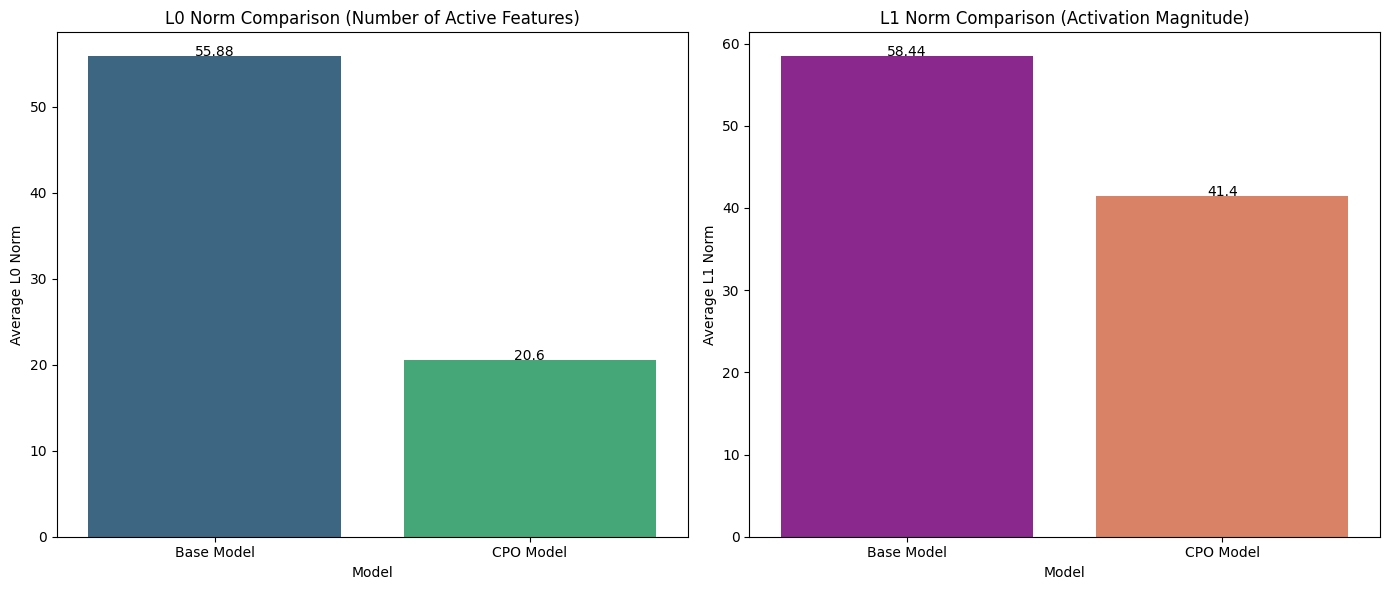

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for plotting
labels = ['Base Model', 'CPO Model']
l0_norms = [base_l0_norm, cpo_l0_norm]
l1_norms = [base_l1_norm, cpo_l1_norm]

# Create a DataFrame for easier plotting with seaborn
plot_data = pd.DataFrame({
    'Model': labels,
    'L0 Norm': l0_norms,
    'L1 Norm': l1_norms
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot L0 Norms (Sparsity)
sns.barplot(x='Model', y='L0 Norm', data=plot_data, ax=axes[0], palette='viridis')
axes[0].set_title('L0 Norm Comparison (Number of Active Features)')
axes[0].set_ylabel('Average L0 Norm')
for index, row in plot_data.iterrows():
    axes[0].text(row.name, row['L0 Norm'], round(row['L0 Norm'], 2), color='black', ha="center")

# Plot L1 Norms (Magnitude)
sns.barplot(x='Model', y='L1 Norm', data=plot_data, ax=axes[1], palette='plasma')
axes[1].set_title('L1 Norm Comparison (Activation Magnitude)')
axes[1].set_ylabel('Average L1 Norm')
for index, row in plot_data.iterrows():
    axes[1].text(row.name, row['L1 Norm'], round(row['L1 Norm'], 2), color='black', ha="center")

plt.tight_layout()
plt.show()

### Deep Analysis of Latent Space Activations

1. ✅ Get latent activations for both the base model and the 18-24 CPO model with the trained SAE.

2. ✅ Calculate the mean activation for each of the d_sae features across all samples for both the base model's latent activations and the CPO model's latent activations. Compare these mean activations to identify features that show significant changes in their average activity after CPO fine-tuning.

3. ✅ Visualize the differences in mean feature activations (e.g., using a histogram of activation differences or plotting the top N most changed features). This step aims to pinpoint specific features that are either suppressed (errors) or strengthened (corrections) in the CPO model compared to the base model.

4. ✅ Summarize the Data Analysis and plan for Feature Steering.

### d. Analyze Mean Feature Activations



In [99]:
%%script true

import torch
import os

base_latent_activations = None
base_latent_activations = torch.load(BASE_LATENT_ACTIVATIONS_SAVE_PATH)
print(f"Base latent activations loaded. Shape: {base_latent_activations.shape}")

cpo_latent_activations = None
cpo_latent_activations = torch.load(CPO_LATENT_ACTIVATIONS_SAVE_PATH)
print(f"CPO latent activations loaded. Shape: {cpo_latent_activations.shape}")

In [100]:
%%script true

import torch
import os

base_latent_activations_cpu = base_latent_activations.cpu()
cpo_latent_activations_cpu = cpo_latent_activations.cpu()

# 2. Calculate the mean activation for each feature
mean_base_activations = base_latent_activations_cpu.mean(dim=0)
mean_cpo_activations = cpo_latent_activations_cpu.mean(dim=0)
print(f"Mean base activations shape: {mean_base_activations.shape}")
print(f"Mean CPO activations shape: {mean_cpo_activations.shape}")

# 3. Compute the difference between mean CPO activations and mean base activations
activation_differences = mean_cpo_activations - mean_base_activations
print(f"Activation differences shape: {activation_differences.shape}")

# 4. Compute the absolute difference
absolute_activation_differences = torch.abs(activation_differences)
print(f"Absolute activation differences shape: {absolute_activation_differences.shape}")

# Define save directory
save_dir = '/content/drive/MyDrive/CS494/Project/SAE/analysis_results/'
os.makedirs(save_dir, exist_ok=True)

# 5. Save the calculated tensors to files
torch.save(mean_base_activations, os.path.join(save_dir, 'mean_base_activations_23_500.pt'))
torch.save(mean_cpo_activations, os.path.join(save_dir, 'mean_cpo_activations_18-24_23_500.pt'))
torch.save(activation_differences, os.path.join(save_dir, 'activation_differences_23_500.pt'))
torch.save(absolute_activation_differences, os.path.join(save_dir, 'absolute_activation_differences_23_500.pt'))

print("Mean activations, differences, and absolute differences saved successfully.")

In [101]:
%%script true

import torch
import matplotlib.pyplot as plt
import numpy as np
import os

save_dir = '/content/drive/MyDrive/CS494/Project/SAE/analysis_results/'

# Load the previously saved tensors
mean_base_activations = torch.load(os.path.join(save_dir, 'mean_base_activations_23_500.pt'))
mean_cpo_activations = torch.load(os.path.join(save_dir, 'mean_cpo_activations_18-24_23_500.pt'))
activation_differences = torch.load(os.path.join(save_dir, 'activation_differences_23_500.pt'))
absolute_activation_differences = torch.load(os.path.join(save_dir, 'absolute_activation_differences_23_500.pt'))

print("Loaded mean activations and differences for analysis.")
print(f"Mean Base Activations shape: {mean_base_activations.shape}")
print(f"Mean CPO Activations shape: {mean_cpo_activations.shape}")
print(f"Activation Differences shape: {activation_differences.shape}")
print(f"Absolute Activation Differences shape: {absolute_activation_differences.shape}")

### e. Plot Mean Features and Compare

In [102]:
%%script true

import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Sort features by their absolute difference to find the most changed ones
sorted_indices = torch.argsort(absolute_activation_differences, descending=True)
top_n = 50 # Let's look at the top 50 most changed features

top_changed_features_indices = sorted_indices[:top_n]
top_changed_values = activation_differences[top_changed_features_indices]

print(f"\nTop {top_n} features with the largest absolute change in mean activation:")
for i, idx in enumerate(top_changed_features_indices):
    print(f"Feature {idx.item()}: Change = {top_changed_values[i].item():.4f}")

# Plotting the top N most changed features
plt.figure(figsize=(15, 7))
plt.bar(range(top_n), top_changed_values.numpy(), color=['green' if x > 0 else 'red' for x in top_changed_values.numpy()])
plt.xlabel('Feature Index (Ranked by Absolute Change)')
plt.ylabel('Change in Mean Activation (CPO - Base)')
plt.title(f'Top {top_n} Features with Largest Change in Mean Activation after CPO')
plt.xticks(range(top_n), top_changed_features_indices.numpy(), rotation=90, fontsize=8)
plt.axhline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()

# Histogram of activation differences
plt.figure(figsize=(10, 6))
plt.hist(activation_differences.numpy(), bins=100, color='skyblue', edgecolor='black')
plt.title('Distribution of Mean Activation Differences (CPO - Base)')
plt.xlabel('Change in Mean Activation')
plt.ylabel('Number of Features')
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.tight_layout()
plt.show()

# Final Task: Summarize findings
print("\n--- Feature Analysis Summary ---")
print(f"Total features (d_sae): {len(mean_base_activations)}")
print(f"Average mean activation for Base Model features: {mean_base_activations.mean().item():.4f}")
print(f"Average mean activation for CPO Model features: {mean_cpo_activations.mean().item():.4f}")
print(f"Average absolute change in mean activation across all features: {absolute_activation_differences.mean().item():.4f}")

positive_changes = (activation_differences > 0).sum().item()
negative_changes = (activation_differences < 0).sum().item()
zero_changes = (activation_differences == 0).sum().item()

print(f"Number of features with increased mean activation (CPO > Base): {positive_changes}")
print(f"Number of features with decreased mean activation (CPO < Base): {negative_changes}")
print(f"Number of features with no change in mean activation: {zero_changes}")

print("\nImplications:")
print(f"The bar chart visually presents the features that have become significantly more active (green bars) or less active (red bars) in the CPO model compared to the base model. Features with positive change likely correspond to 'correction features' that were reinforced by CPO training, leading to more preferred outputs. Conversely, features with negative change might represent 'error features' that CPO training suppressed, reducing the generation of unpreferred outputs. The histogram shows the overall distribution of these changes. Further in-depth analysis, such as examining the contexts that activate these specific features, would be necessary to fully understand their functional roles.")

In [98]:
%%script true

import os
import torch
import numpy as np

save_dir = '/content/drive/MyDrive/CS494/Project/SAE/analysis_results/'
os.makedirs(save_dir, exist_ok=True)

# Save mean activations
torch.save(mean_base_activations, os.path.join(save_dir, 'mean_base_activations_23_500.pt'))
torch.save(mean_cpo_activations, os.path.join(save_dir, 'mean_cpo_activations_18-24_23_500.pt'))

# Save activation differences
torch.save(activation_differences, os.path.join(save_dir, 'activation_differences_23_500.pt'))
torch.save(absolute_activation_differences, os.path.join(save_dir, 'absolute_activation_differences_23_500.pt'))

# Save top changed features (indices and values)
sorted_indices = torch.argsort(absolute_activation_differences, descending=True)
top_n = 50
top_changed_features_indices = sorted_indices[:top_n]
top_changed_values = activation_differences[top_changed_features_indices]

torch.save(top_changed_features_indices, os.path.join(save_dir, 'top_changed_features_indices_23_500.pt'))
torch.save(top_changed_values, os.path.join(save_dir, 'top_changed_values_23_500.pt'))

# Save summary statistics to a text file
summary_path = os.path.join(save_dir, 'feature_analysis_summary.txt')
with open(summary_path, 'w') as f:
    f.write(f"--- Feature Analysis Summary ---\n")
    f.write(f"Total features (d_sae): {len(mean_base_activations)}\n")
    f.write(f"Average mean activation for Base Model features: {mean_base_activations.mean().item():.4f}\n")
    f.write(f"Average mean activation for CPO Model features: {mean_cpo_activations.mean().item():.4f}\n")
    f.write(f"Average absolute change in mean activation across all features: {absolute_activation_differences.mean().item():.4f}\n")

    positive_changes = (activation_differences > 0).sum().item()
    negative_changes = (activation_differences < 0).sum().item()
    zero_changes = (activation_differences == 0).sum().item()

    f.write(f"Number of features with increased mean activation (CPO > Base): {positive_changes}\n")
    f.write(f"Number of features with decreased mean activation (CPO < Base): {negative_changes}\n")
    f.write(f"Number of features with no change in mean activation: {zero_changes}\n")

print(f"All feature analysis data saved to {save_dir}")


Top 50 features with the largest absolute change in mean activation:

Feature 18666: Change = -0.4738

Feature 22644: Change = -0.4380

Feature 23617: Change = -0.3156

Feature 20966: Change = 0.2545

Feature 16946: Change = -0.2515

Feature 19913: Change = -0.2258

Feature 26745: Change = -0.1547

Feature 2884: Change = -0.1344

Feature 4810: Change = -0.1296

Feature 11185: Change = -0.1248

Feature 16705: Change = -0.1192

Feature 18983: Change = 0.1163

Feature 4516: Change = 0.1060

Feature 18480: Change = 0.1039

Feature 5995: Change = -0.0997

Feature 20842: Change = -0.0991

Feature 28398: Change = -0.0758

Feature 4047: Change = -0.0697

Feature 27042: Change = 0.0638

Feature 11755: Change = -0.0597

Feature 13797: Change = -0.0573

Feature 17004: Change = -0.0547

Feature 12202: Change = 0.0519

Feature 22645: Change = 0.0514

Feature 15703: Change = 0.0513

Feature 27104: Change = 0.0479

Feature 12016: Change = 0.0471

Feature 2408: Change = -0.0434

Feature 23670: Change = 0.0427

Feature 5283: Change = -0.0423

Feature 4979: Change = 0.0419

Feature 25845: Change = -0.0414

Feature 9352: Change = -0.0409

Feature 24194: Change = 0.0368

Feature 18586: Change = -0.0366

Feature 4456: Change = 0.0359

Feature 25904: Change = -0.0355

Feature 4140: Change = 0.0345

Feature 12053: Change = -0.0337

Feature 6512: Change = 0.0306

Feature 7400: Change = 0.0295

Feature 6986: Change = 0.0287

Feature 26316: Change = 0.0279

Feature 10737: Change = -0.0273

Feature 5340: Change = 0.0270

Feature 27883: Change = 0.0266

Feature 1756: Change = 0.0260

Feature 23206: Change = 0.0259

Feature 14551: Change = 0.0252

Feature 19148: Change = 0.0248



--- Feature Analysis Summary ---

Total features (d_sae): 28672

Average mean activation for Base Model features: 0.0020

Average mean activation for CPO Model features: 0.0014

Average absolute change in mean activation across all features: 0.
0009

Number of features with increased mean activation (CPO > Base): 892

Number of features with decreased mean activation (CPO < Base): 27780

Number of features with no change in mean activation: 0

Implications:

The bar chart visually presents the features that have become significantly more active (green bars) or less active (red bars) in the CPO model compared to the base model. Features with positive change likely correspond to 'correction features' that were reinforced by CPO training, leading to more preferred outputs. Conversely, features with negative change might represent 'error features' that CPO training suppressed, reducing the generation of unpreferred outputs. The histogram shows the overall distribution of these changes. Further in-depth analysis, such as examining the contexts that activate these specific features, would be necessary to fully understand their functional roles.

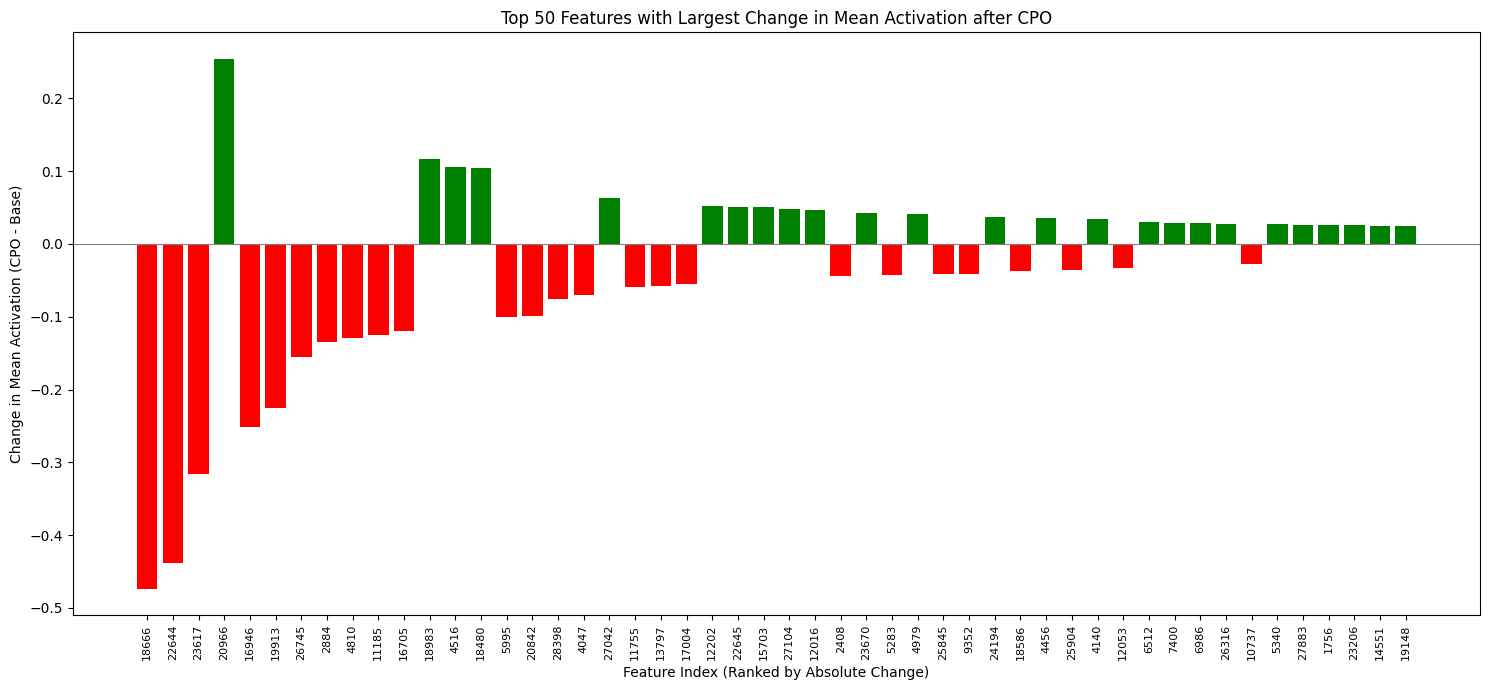

## Phase 3: Feature **Steering**

In [97]:
import gc
from peft import PeftModel

LAYER_TO_HOOK = 23 # the 24th layer
CPO_MODEL_PATH = '/content/drive/MyDrive/CS494/Project/qwen2.5-7b-cpo-18-24'

BASE_MODEL_ACTIVATIONS_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/base_model_activations_23_500.pt'
CPO_MODEL_ACTIVATIONS_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/cpo_model_activations_18-24_23_500.pt'
SAE_MODEL_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/sae_models/config3/model.pth'

d_model=3584
d_sae=28672

BASE_LATENT_ACTIVATIONS_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/base_latent_activations_23_500.pt'
CPO_LATENT_ACTIVATIONS_SAVE_PATH = '/content/drive/MyDrive/CS494/Project/SAE/activations/cpo_latent_activations_18-24_23_500.pt'
os.makedirs(os.path.dirname(BASE_LATENT_ACTIVATIONS_SAVE_PATH), exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

save_dir = '/content/drive/MyDrive/CS494/Project/SAE/analysis_results/'
os.makedirs(save_dir, exist_ok=True)

Using device: cuda


In [ ]:
mismatch_df.head()

,question,true_cot_steps,true_step_answers,true_final_answer,base_response,base_step_answers,base_cot_steps,base_final_answer,cpo_response,cpo_step_answers,cpo_cot_steps,cpo_final_answer
0,Lee mows one lawn and charges $33. Last week h...,"['Step 1: 33 * 16 = $528', 'Step 2: 3 * 10 = $...","[528.0, 30.0, 558.0, 558.0, 558.0]",558.0,Step 1: Calculate the earnings from mowing law...,"[16.0, 10.0, 10.0, 10.0]",[Step 1: Calculate the earnings from mowing la...,10.0,Step 1: Calculate the total earnings from mowi...,"[528.0, 30.0, 558.0, 558.0, 1.0, 2.0, 72.0, 1....",[Step 1: Calculate the total earnings from mow...,558.0
1,Alice has 20 quarters. She wants to exchange t...,['Step 1: A quarter is worth five nickels beca...,"[5.0, 100.0, 20.0, 80.0, 60.0, 4.0, 64.0, 64.0]",64.0,Step 1: Calculate the total amount of money Al...,"[25.0, 100.0, 80.0, 5.0, 5.0]",[Step 1: Calculate the total amount of money A...,5.0,Step 1: Calculate the number of nickels Alice ...,"[100.0, 20.0, 60.0, 4.0, 64.0, 64.0, 20.0, 2.0]",[Step 1: Calculate the number of nickels Alice...,2.0
2,Henry took 9 pills a day for 14 days. Of these...,"['Step 1: There were 9-4 = 5 other pills', 'St...","[5.0, 7.0, 35.0, 6.0, 41.0, 41.0]",41.0,Step 1: Calculate the cost of the first type o...,"[50.0, 0.0, 56.0, 98.0, 50.0, 0.0, 0.0, 0.0, 5...",[Step 1: Calculate the cost of the first type ...,56.0,Step 1: Calculate the cost of the first type o...,"[0.0, 0.0, 5.0, 0.0, 0.0, 0.0, 1.0, 2.0, 3.0, ...",[Step 1: Calculate the cost of the first type ...,4.0
3,A young girl pours 23 blue beads and 16 yellow...,['Step 1: There are 23+16=39 beads in the bowl...,"[39.0, 13.0, 3.0, 10.0, 10.0]",10.0,Step 1: Calculate the total number of beads in...,"[39.0, 18.0, 7.0, 7.0]",[Step 1: Calculate the total number of beads i...,7.0,Step 1: The girl had 23 + 16 = 39 beads in tot...,"[39.0, 13.0, 3.0, 10.0, 10.0]",[Step 1: The girl had 23 + 16 = 39 beads in to...,10.0
4,"In a section of the forest, there are 100 weas...",['Step 1: 3 foxes catch 4 weasels each every w...,"[12.0, 36.0, 6.0, 18.0, 64.0, 32.0, 96.0, 96.0]",96.0,Step 1: Calculate the total number of weasels ...,"[12.0, 6.0, 36.0, 18.0, 64.0, 32.0, 7.0]",[Step 1: Calculate the total number of weasels...,7.0,Step 1: First find the total number of rabbits...,"[18.0, 54.0, 96.0, 96.0, 3.0, 64.0, 32.0, 6.0]",[Step 1: First find the total number of rabbit...,6.0


In [96]:
mismatch_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   question           419 non-null    object 
 1   true_cot_steps     419 non-null    object 
 2   true_step_answers  419 non-null    object 
 3   true_final_answer  419 non-null    float64
 4   base_response      419 non-null    object 
 5   base_step_answers  419 non-null    object 
 6   base_cot_steps     419 non-null    object 
 7   base_final_answer  419 non-null    float64
 8   cpo_response       419 non-null    object 
 9   cpo_step_answers   419 non-null    object 
 10  cpo_cot_steps      419 non-null    object 
 11  cpo_final_answer   419 non-null    float64
dtypes: float64(3), object(9)
memory usage: 39.4+ KB


In [105]:
import torch
import os

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

save_dir = '/content/drive/MyDrive/CS494/Project/SAE/analysis_results/'

# 1. Load the data directly to the GPU
print("Loading feature analysis data to GPU...")
# map_location ensures it loads directly to CUDA
all_indices = torch.load(os.path.join(save_dir, 'top_changed_features_indices_23_500.pt'), map_location=device)
all_values = torch.load(os.path.join(save_dir, 'top_changed_values_23_500.pt'), map_location=device)

# 2. Separate into Positive (Correction) and Negative (Error)
# These operations now happen on the GPU
positive_mask = all_values > 0
negative_mask = all_values < 0

# 3. Get Correction Features (Top 20 most positive)
pos_vals = all_values[positive_mask]
pos_idxs = all_indices[positive_mask]

# Sort on GPU (Descending = largest positive values first)
sorted_pos_indices = torch.argsort(pos_vals, descending=True)

# Extract top 20 and convert to list (Hook needs a standard list to loop over)
amplify_list = pos_idxs[sorted_pos_indices][:20].tolist()

# 4. Get Error Features (Top 20 most negative)
neg_vals = all_values[negative_mask]
neg_idxs = all_indices[negative_mask]

# Sort on GPU (Ascending = most negative values first, e.g. -0.5 before -0.1)
sorted_neg_indices = torch.argsort(neg_vals, descending=False)

# Extract top 20 and convert to list
suppress_list = neg_idxs[sorted_neg_indices][:20].tolist()

# 5. Verify
print(f"\n--- Feature Selection Complete ---")
print(f"Top 3 Correction Features (to Amplify): {amplify_list[:3]}")
print(f"Top 3 Error Features (to Suppress): {suppress_list[:3]}")

# Check against your known features (indices are integers, so comparison works fine)
if 20966 in amplify_list:
    print("Confirmed: Feature 20966 is in the Top 20 Correction list.")
else:
    print("Note: Feature 20966 is NOT in the Top 20 (it might be in the Top 50).")

if 18666 in suppress_list:
    print("Confirmed: Feature 18666 is in the Top 20 Suppression list.")
else:
    print("Note: Feature 18666 is NOT in the Top 20.")

Using device: cuda
Loading feature analysis data to GPU...

--- Feature Selection Complete ---
Top 3 Correction Features (to Amplify): [20966, 18983, 4516]
Top 3 Error Features (to Suppress): [18666, 22644, 23617]
Confirmed: Feature 20966 is in the Top 20 Correction list.
Confirmed: Feature 18666 is in the Top 20 Suppression list.


In [ ]:
# print("Job complete. Disconnecting runtime...")
# runtime.unassign()

# Task
Run a simultaneous steered inference experiment using the `amplify_list` and `suppress_list` (containing the top 20 correction and error features respectively) with defined `amp_strength` and `suppress_strength` values. Analyze the accuracy results by comparing them with the base model and individual steering results, and summarize the findings.

## Update Feature Steering Functions

### Subtask:
Modify the steer_mlp_output_hook to accept lists of features for simultaneous amplification and suppression. Update cpo_inference_steered to correctly pass these lists and steering strengths to the hook.


**Reasoning**:
The subtask requires modifying the steering functions to handle both amplification and suppression of multiple features. I will define the updated `steer_mlp_output_hook` and `cpo_inference_steered` functions to incorporate these changes.



In [ ]:
%%script true

import torch
import gc
from peft import PeftModel

# Assuming sae_model, d_model, d_sae, and device are already defined and loaded
# from previous cells (e.g., sae_model from config3)

# Load SAE model if not already loaded (as per previous step)
if 'sae_model' not in globals() or sae_model is None:
    print(f"Loading SAE model from: {SAE_MODEL_SAVE_PATH}")
    sae_model = SAE(d_model=d_model, d_sae=d_sae, sparsity_lambda=3e-3).to(device)
    sae_model.load_state_dict(torch.load(SAE_MODEL_SAVE_PATH, map_location=device))
    sae_model.eval()
    print("SAE model loaded and set to evaluation mode.")

def steer_mlp_output_hook(model_output, amplify_features, amplify_strength, suppress_features, suppress_strength):
    """
    Hook function to steer MLP output activations using SAE latent space manipulation.
    """
    def hook(module, input, output):
        with torch.no_grad():
            # Ensure output is a tensor, typically it's a tuple for MLP in transformer
            if isinstance(output, tuple):
                original_activations = output[0]
            else:
                original_activations = output

            # Ensure activations are on the correct device and float type
            activations_flat = original_activations.view(-1, d_model).to(device).float()

            # Encode activations to latent space
            _, latent_activations = sae_model(activations_flat)

            # Apply amplification
            if amplify_features and amplify_strength != 0:
                for feature_idx in amplify_features:
                    if 0 <= feature_idx < d_sae:
                        latent_activations[:, feature_idx] *= amplify_strength

            # Apply suppression
            if suppress_features and suppress_strength != 0:
                for feature_idx in suppress_features:
                    if 0 <= feature_idx < d_sae:
                        latent_activations[:, feature_idx] *= suppress_strength

            # Decode modified latent activations back to original space
            modified_activations_flat = sae_model.decoder(sae_model.relu(latent_activations))

            # Reshape back to original output shape
            modified_activations = modified_activations_flat.view(original_activations.shape)

            # If original output was a tuple, replace the first element
            if isinstance(output, tuple):
                new_output = (modified_activations,) + output[1:]
            else:
                new_output = modified_activations
        return new_output
    return hook

def cpo_inference_steered(model_to_run, df, amplify_features, amplify_strength, suppress_features, suppress_strength, batch_size=4, num_responses=1):
  results = []
  tokenizer.padding_side = "left"
  questions = df['question'].tolist()
  true_final_answers = df['true_final_answer'].tolist()
  true_cot_steps = df['true_cot_steps'].tolist()

  # Attach the steering hook to the target layer
  if isinstance(model_to_run, PeftModel):
      target_module = model_to_run.get_base_model().model.layers[LAYER_TO_HOOK].mlp.down_proj
  else:
      target_module = model_to_run.model.layers[LAYER_TO_HOOK].mlp.down_proj

  hook_handle = target_module.register_forward_hook(steer_mlp_output_hook(model_to_run, amplify_features, amplify_strength, suppress_features, suppress_strength))

  print(f"Starting CPO inference with steering on Layer {LAYER_TO_HOOK}...")

  for i in tqdm(range(0, len(questions), batch_size), desc="Processing Batches (Steered)"):

    batch_questions = questions[i : i + batch_size]

    batch_prompts = [generate_full_prompt(q) for q in batch_questions]

    inputs = tokenizer(
        batch_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model_to_run.device)

    prompt_length = inputs['input_ids'].shape[1]

    with torch.no_grad():
      outputs = model_to_run.generate(
          **inputs,
          max_new_tokens=300,
          do_sample=True,
          temperature=1.0, # Fixed temperature as per previous cells (should be 1.0 for consistency, or adjust as needed)
          pad_token_id=tokenizer.pad_token_id,
          num_return_sequences=num_responses
      )

    generated_tokens = outputs[:, prompt_length:]

    generated_texts = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

    for j, question in enumerate(batch_questions):
        start_idx = j * num_responses
        end_idx = start_idx + num_responses
        responses = generated_texts[start_idx : end_idx]

        true_final_answer = true_final_answers[i + j]

        for response in responses:

          response = response.split('Question')[0].strip()

          generated_steps, generated_step_answers, generated_final_answer = get_step_data(response)

          results.append({
            'index': i + j + 1,
            'question': question,
            'true_final_answer': true_final_answer,
            'generated_response': response,
            'generated_final_answer': generated_final_answer,
            'is_correct': generated_final_answer == true_final_answer
          })

  hook_handle.remove()
  print("Hook removed safely.")
  return pd.DataFrame(results)

print("Feature steering functions defined and SAE model loaded.")

**Reasoning**:
The subtask requests to run a simultaneous steered inference experiment. This involves loading the base model, setting amplification and suppression strengths, and then calling the modified `cpo_inference_steered` function with the appropriate arguments. After running the inference, I will calculate and print the accuracy.



**Reasoning**:
The previous code failed because of a dtype mismatch between `float32` activations and the `float16` model weights. I will modify the `steer_mlp_output_hook` to cast the `modified_activations` back to the original dtype (`torch.float16`) before returning, ensuring consistency with the quantized model's expected input.



**Reasoning**:
The previous code block failed due to a dtype mismatch. I have already provided the corrected version of the `steer_mlp_output_hook` function in the previous turn. Now, I will re-run the steering experiment using the corrected function, which involves loading the base model, setting amplification and suppression strengths, calling `cpo_inference_steered`, calculating the accuracy, and cleaning up the model.



In [ ]:
%%script true

import gc
from peft import PeftModel

# Clear memory before loading new model
if 'model_cpo' in globals(): del model_cpo
if 'model' in globals(): del model
if 'base_model' in globals(): del base_model
torch.cuda.empty_cache()
gc.collect()

print(f"Loading base model: {MODEL_ID} for steering...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)
base_model.eval()

# Define steering strengths (these can be tuned)
amp_strength = 2.0  # Amplify by 2x
suppress_strength = 0.0 # Suppress to 0.0x (completely remove)

print("Starting Push-Pull Inference on Layer 23...")
results_steer_push_pull_df = cpo_inference_steered(
    base_model,
    mismatch_df,
    amplify_list,
    amp_strength,
    suppress_list,
    suppress_strength,
    batch_size=48 # Using a batch size suitable for inference
)

# Calculate accuracy for the steered results
acc_steer_push_pull = results_steer_push_pull_df['is_correct'].mean()
print(f"Push-Pull Steering Accuracy: {acc_steer_push_pull:.4f}")

# Clean up
cleanup(base_model)

In [ ]:
%%script true

csv_save_path = '/content/drive/MyDrive/CS494/Project/hybrid_steered_inference_results.csv'
results_steer_push_pull_df.to_csv(csv_save_path, index=False)
print(f"Hybrid steered inference results saved to: {csv_save_path}")

In [ ]:
%%script true
results_steer_push_pull_df.head()

In [ ]:
%%script true

mismatch_df.head()

changing amplifying factor, adding sae error



In [ ]:
%%script true

import torch
import gc
import pandas as pd
from peft import PeftModel
from tqdm.notebook import tqdm

# --- 1. The Fixed Hybrid Hook (Removed 'model_to_run' arg) ---
def steer_hybrid_hook(amplify_features, amp_scale, amp_bias, suppress_features, suppress_strength):
    """
    Hybrid Hook Logic:
    1. Calculate SAE Error (Residual).
    2. Hybrid Amplification (Scale active, Bias inactive).
    3. Suppression.
    4. Add Residual back.
    """
    def hook(module, input, output):
        # Handle tuple output
        if isinstance(output, tuple):
            original_activations = output[0]
        else:
            original_activations = output

        # Detach and prepare
        original_ref = original_activations.detach()
        original_dtype = original_ref.dtype
        activations_flat = original_ref.view(-1, d_model).to(device).float()

        with torch.no_grad():
            # A. Encode
            _, latent_activations = sae_model(activations_flat)

            # B. Calculate SAE Error (Residual)
            original_reconstruction = sae_model.decoder(latent_activations)
            sae_error = activations_flat - original_reconstruction

            # C. Hybrid Steering
            steered_latents = latent_activations.clone()

            # --- HYBRID AMPLIFICATION ---
            if amplify_features is not None:
                for feature_idx in amplify_features:
                    if 0 <= feature_idx < d_sae:
                        # Mask for hybrid logic
                        is_active = steered_latents[:, feature_idx] > 0

                        # Case 1: Active -> Scale it up
                        steered_latents[is_active, feature_idx] *= amp_scale

                        # Case 2: Inactive -> Wake it up (Bias)
                        steered_latents[~is_active, feature_idx] += amp_bias

            # --- SUPPRESSION ---
            if suppress_features is not None:
                for feature_idx in suppress_features:
                    if 0 <= feature_idx < d_sae:
                        steered_latents[:, feature_idx] *= suppress_strength

            # Re-apply ReLU
            steered_latents = sae_model.relu(steered_latents)

            # D. Decode & Add Error
            steered_reconstruction = sae_model.decoder(steered_latents)
            final_output_flat = steered_reconstruction + sae_error

        # Restore shape
        final_output = final_output_flat.to(original_dtype).view(original_activations.shape)

        if isinstance(output, tuple):
            return (final_output,) + output[1:]
        else:
            return final_output
    return hook

# --- 2. The Inference Loop (Updated Call) ---
def cpo_inference_hybrid(model_to_run, df, amplify_features, amp_scale, amp_bias, suppress_features, suppress_strength, batch_size=4):
    results = []
    tokenizer.padding_side = "left"
    questions = df['question'].tolist()
    true_final_answers = df['true_final_answer'].tolist()

    if isinstance(model_to_run, PeftModel):
        target_module = model_to_run.get_base_model().model.layers[LAYER_TO_HOOK].mlp.down_proj
    else:
        target_module = model_to_run.model.layers[LAYER_TO_HOOK].mlp.down_proj

    # Register Hook (Now the arguments match perfectly)
    hook_handle = target_module.register_forward_hook(
        steer_hybrid_hook(
            amplify_features, amp_scale, amp_bias,
            suppress_features, suppress_strength
        )
    )

    print(f"Starting Hybrid Inference on Layer {LAYER_TO_HOOK}...")

    try:
        for i in tqdm(range(0, len(questions), batch_size), desc="Steering..."):
            batch_questions = questions[i : i + batch_size]
            batch_prompts = [generate_full_prompt(q) for q in batch_questions]

            inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True).to(model_to_run.device)
            prompt_len = inputs['input_ids'].shape[1]

            with torch.no_grad():
                outputs = model_to_run.generate(
                    **inputs, max_new_tokens=300, do_sample=False, pad_token_id=tokenizer.pad_token_id
                )

            generated_texts = tokenizer.batch_decode(outputs[:, prompt_len:], skip_special_tokens=True)

            for j, text in enumerate(generated_texts):
                true_ans = true_final_answers[i + j]
                response_clean = text.split('Question')[0].strip()
                _, _, gen_ans = get_step_data(response_clean)

                is_correct = False
                try:
                    num_gen = float(str(gen_ans).replace(',', ''))
                    num_true = float(str(true_ans).replace(',', ''))
                    if abs(num_gen - num_true) < 1e-4:
                        is_correct = True
                except:
                    if str(gen_ans).strip() == str(true_ans).strip():
                        is_correct = True

                results.append({
                    'index': i + j + 1,
                    'is_correct': is_correct
                })
    finally:
        hook_handle.remove()
        print("Hook removed safely.")

    return pd.DataFrame(results)

In [ ]:
%%script true

# Clear memory first
if 'base_model' in globals(): del base_model
torch.cuda.empty_cache()
gc.collect()

print(f"Loading base model: {MODEL_ID}...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)
base_model.eval()

# --- HYBRID PARAMETERS ---
AMP_SCALE = 1.5      # Scale active features
AMP_BIAS  = 0.08     # Wake up inactive features (Use small value for addition)
SUPPRESS_STR = 0.0   # Kill error features

print("Running Hybrid Steering...")
results_hybrid_df = cpo_inference_hybrid(
    base_model,
    mismatch_df,
    amplify_features=amplify_list,
    amp_scale=AMP_SCALE,
    amp_bias=AMP_BIAS,
    suppress_features=suppress_list,
    suppress_strength=SUPPRESS_STR,
    batch_size=16
)

acc = results_hybrid_df['is_correct'].mean()
print(f"Hybrid Steering Accuracy: {acc:.4f}")

In [ ]:
%%script true
results_hybrid_df.head(

)

vectorized hook

In [ ]:
%%script true

import torch
import gc
import pandas as pd
from peft import PeftModel
from tqdm.notebook import tqdm

# Ensure SAE is loaded
if 'sae_model' not in globals() or sae_model is None:
    print(f"Loading SAE model from: {SAE_MODEL_SAVE_PATH}")
    sae_model = SAE(d_model=d_model, d_sae=d_sae, sparsity_lambda=3e-3).to(device)
    sae_model.load_state_dict(torch.load(SAE_MODEL_SAVE_PATH, map_location=device))
    sae_model.eval()
    print("SAE model loaded.")

def steer_hybrid_hook_vectorized(amplify_indices_tensor, amp_scale, amp_bias, suppress_indices_tensor, suppress_strength):
    """
    Vectorized Hybrid Hook:
    - Removes Python loops.
    - Uses PyTorch advanced indexing for simultaneous updates.
    """
    def hook(module, input, output):
        # Handle tuple output
        if isinstance(output, tuple):
            original_activations = output[0]
        else:
            original_activations = output

        # Detach and prepare
        original_ref = original_activations.detach()
        original_dtype = original_ref.dtype
        activations_flat = original_ref.view(-1, d_model).to(device).float()

        with torch.no_grad():
            # A. Encode
            _, latent_activations = sae_model(activations_flat)

            # B. Calculate SAE Error (Residual)
            # Reconstruct UNMODIFIED latents first
            original_reconstruction = sae_model.decoder(latent_activations)
            sae_error = activations_flat - original_reconstruction

            # C. Vectorized Steering
            steered_latents = latent_activations.clone()

            # --- VECTORIZED AMPLIFICATION ---
            if amplify_indices_tensor is not None and len(amplify_indices_tensor) > 0:
                # 1. Extract all target columns at once (Creates a copy)
                # Shape: [Batch_Size, Num_Features_To_Amplify]
                target_features = steered_latents[:, amplify_indices_tensor]

                # 2. Create Vectorized Mask
                is_active = target_features > 0

                # 3. Apply Logic (All at once)
                # Active -> Scale
                target_features[is_active] *= amp_scale
                # Inactive -> Bias
                target_features[~is_active] += amp_bias

                # 4. Write back to main tensor
                steered_latents[:, amplify_indices_tensor] = target_features

            # --- VECTORIZED SUPPRESSION ---
            if suppress_indices_tensor is not None and len(suppress_indices_tensor) > 0:
                # Direct multiplication on the indices
                steered_latents[:, suppress_indices_tensor] *= suppress_strength

            # Re-apply ReLU
            steered_latents = sae_model.relu(steered_latents)

            # D. Decode & Add Error
            steered_reconstruction = sae_model.decoder(steered_latents)
            final_output_flat = steered_reconstruction + sae_error

        # Restore shape
        final_output = final_output_flat.to(original_dtype).view(original_activations.shape)

        if isinstance(output, tuple):
            return (final_output,) + output[1:]
        else:
            return final_output
    return hook

In [ ]:
def cpo_inference_vectorized(model_to_run, df, amplify_list, amp_scale, amp_bias, suppress_list, suppress_strength, batch_size=4):
    results = []
    tokenizer.padding_side = "left"
    questions = df['question'].tolist()
    true_final_answers = df['true_final_answer'].tolist()

    if isinstance(model_to_run, PeftModel):
        target_module = model_to_run.get_base_model().model.layers[LAYER_TO_HOOK].mlp.down_proj
    else:
        target_module = model_to_run.model.layers[LAYER_TO_HOOK].mlp.down_proj

    # --- OPTIMIZATION: PRE-CONVERT LISTS TO GPU TENSORS ---
    amp_tensor = None
    if amplify_list is not None:
        amp_tensor = torch.tensor(amplify_list, device=device, dtype=torch.long)

    sup_tensor = None
    if suppress_list is not None:
        sup_tensor = torch.tensor(suppress_list, device=device, dtype=torch.long)
    # ------------------------------------------------------

    # Register Vectorized Hook
    hook_handle = target_module.register_forward_hook(
        steer_hybrid_hook_vectorized(
            amp_tensor, amp_scale, amp_bias,
            sup_tensor, suppress_strength
        )
    )

    print(f"Starting Vectorized Hybrid Inference on Layer {LAYER_TO_HOOK}...")

    try:
        for i in tqdm(range(0, len(questions), batch_size), desc="Steering..."):
            batch_questions = questions[i : i + batch_size]
            batch_prompts = [generate_full_prompt(q) for q in batch_questions]

            inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True).to(model_to_run.device)
            prompt_len = inputs['input_ids'].shape[1]

            with torch.no_grad():
                outputs = model_to_run.generate(
                    **inputs, max_new_tokens=300, do_sample=False, pad_token_id=tokenizer.pad_token_id
                )

            generated_texts = tokenizer.batch_decode(outputs[:, prompt_len:], skip_special_tokens=True)

            for j, text in enumerate(generated_texts):
                true_ans = true_final_answers[i + j]

                # Clean the response (Remove hallucinated next questions)
                response_clean = text.split('Question')[0].strip()

                # Extract DETAILED step data (Reasoning Trace)
                # Ensure your get_step_data returns 3 values!
                gen_steps, gen_step_ans, gen_ans = get_step_data(response_clean)

                # --- Robust Accuracy Check ---
                is_correct = False
                try:
                    num_gen = float(str(gen_ans).replace(',', ''))
                    num_true = float(str(true_ans).replace(',', ''))
                    if abs(num_gen - num_true) < 1e-4:
                        is_correct = True
                except:
                    if str(gen_ans).strip() == str(true_ans).strip():
                        is_correct = True

                # --- BUILD THE RICH DATAFRAME ---
                results.append({
                    'id': i + j,
                    'question': batch_questions[j],
                    'true_answer': true_ans,
                    'generated_answer': gen_ans,       # The extracted final number
                    'is_correct': is_correct,
                    'full_response': response_clean,   # Full text to read the tone
                    'reasoning_steps': gen_steps,      # List of text steps
                    'step_calculations': gen_step_ans, # List of math at every step
                    'steering_config': f"AmpScale:{amp_scale}/Bias:{amp_bias}" # Metadata
                })
    finally:
        hook_handle.remove()
        print("Hook removed safely.")

    return pd.DataFrame(results)

In [ ]:
%%script true

# Clear memory first
if 'base_model' in globals(): del base_model
torch.cuda.empty_cache()
gc.collect()

print(f"Loading base model: {MODEL_ID}...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP,
    trust_remote_code=True
)
base_model.eval()

# --- HYBRID PARAMETERS ---
AMP_SCALE = 1.5      # Scale active features
AMP_BIAS  = 0.08     # Wake up inactive features
SUPPRESS_STR = 0.0   # Kill error features

print("Running Fast Vectorized Steering...")
results_hybrid_df = cpo_inference_vectorized(
    base_model,
    mismatch_df,
    amplify_list=amplify_list,   # Pass the lists here
    amp_scale=AMP_SCALE,
    amp_bias=AMP_BIAS,
    suppress_list=suppress_list, # Pass the lists here
    suppress_strength=SUPPRESS_STR,
    batch_size=16
)

acc = results_hybrid_df['is_correct'].mean()
print(f"Hybrid Steering Accuracy: {acc:.4f}")

In [ ]:
%%script true
csv_save_path = '/content/drive/MyDrive/CS494/Project/hybrid_steered_results.csv'
results_hybrid_df.to_csv(csv_save_path, index=False)
print(f"Hybrid steered inference results saved to: {csv_save_path}")

### Checking CSV

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CS494/Project/hybrid_steered_results.csv')

In [ ]:
df.head()

,id,question,true_answer,generated_answer,is_correct,full_response,reasoning_steps,step_calculations,steering_config
0,0,Lee mows one lawn and charges $33. Last week h...,558.0,578.0,False,Step 1: Calculate the earnings from mowing law...,['Step 1: Calculate the earnings from mowing l...,"[1.0, 33.0, 3.0, 10.0, 5.0, 10.0, 578.0]",AmpScale:1.5/Bias:0.08
1,1,Alice has 20 quarters. She wants to exchange t...,64.0,80.0,False,Step 1: Calculate the number of nickels Alice ...,['Step 1: Calculate the number of nickels Alic...,"[20.0, 4.0, 12.0, 80.0, 80.0, 80.0]",AmpScale:1.5/Bias:0.08
2,2,Henry took 9 pills a day for 14 days. Of these...,41.0,2.0,False,Step 1: Calculate the cost of the 4 pills that...,['Step 1: Calculate the cost of the 4 pills th...,"[50.0, 50.0, 3.0, 50.0, 5.0, 4.0, 5.0, 14.0, 4...",AmpScale:1.5/Bias:0.08
3,3,A young girl pours 23 blue beads and 16 yellow...,10.0,7.0,False,Step 1: Calculate the total number of beads in...,['Step 1: Calculate the total number of beads ...,"[39.0, 18.0, 21.0, 7.0, 7.0]",AmpScale:1.5/Bias:0.08
4,4,"In a section of the forest, there are 100 weas...",96.0,3.0,False,Step 1: Calculate the number of weasels caught...,['Step 1: Calculate the number of weasels caug...,"[4.0, 12.0, 36.0, 64.0, 2.0, 6.0, 18.0, 3.0]",AmpScale:1.5/Bias:0.08


In [ ]:
import ast

correct = 0
correct_in_df = 0

results_list = []

for index, row in df.iterrows():
    steps = ast.literal_eval(row['reasoning_steps'])
    cleaned_steps = clean_cot_steps(steps)

    possible_answers = extract_numbers_from_string(row['full_response'])
    is_correct = row['true_answer'] in possible_answers
    if is_correct:
      correct += 1

    correct_in_df += 1 if bool(row['is_correct']) else 0

    results_dict = {
        'id': row['id'],
        'question': row['question'],
        'true_answer': row['true_answer'],
        'generated_answer': row['generated_answer'],
        'is_correct': is_correct,
        'full_response': row['full_response'],
        'reasoning_steps': cleaned_steps,
        'step_calculations': possible_answers,
        'steering_config': row['steering_config']
    }

    results_list.append(results_dict)

correct/len(df)

0.7303102625298329

In [ ]:
resultant_df = pd.DataFrame(results_list)
resultant_df.head()

,id,question,true_answer,generated_answer,is_correct,full_response,reasoning_steps,step_calculations,steering_config
0,0,Lee mows one lawn and charges $33. Last week h...,558.0,578.0,False,Step 1: Calculate the earnings from mowing law...,[Step 1: Calculate the earnings from mowing la...,"[1.0, 2.0, 33.0, 16.0, 16.0, 33.0, 3.0, 4.0, 1...",AmpScale:1.5/Bias:0.08
1,1,Alice has 20 quarters. She wants to exchange t...,64.0,80.0,False,Step 1: Calculate the number of nickels Alice ...,[Step 1: Calculate the number of nickels Alice...,"[1.0, 20.0, 1.0, 5.0, 20.0, 20.0, 5.0, 100.0, ...",AmpScale:1.5/Bias:0.08
2,2,Henry took 9 pills a day for 14 days. Of these...,41.0,2.0,False,Step 1: Calculate the cost of the 4 pills that...,[Step 1: Calculate the cost of the 4 pills tha...,"[1.0, 4.0, 1.5, 2.0, 1.5, 4.0, 4.0, 1.5, 3.0, ...",AmpScale:1.5/Bias:0.08
3,3,A young girl pours 23 blue beads and 16 yellow...,10.0,7.0,False,Step 1: Calculate the total number of beads in...,[Step 1: Calculate the total number of beads i...,"[1.0, 23.0, 16.0, 39.0, 2.0, 6.0, 3.0, 6.0, 3....",AmpScale:1.5/Bias:0.08
4,4,"In a section of the forest, there are 100 weas...",96.0,3.0,False,Step 1: Calculate the number of weasels caught...,[Step 1: Calculate the number of weasels caugh...,"[1.0, 4.0, 2.0, 3.0, 4.0, 12.0, 3.0, 3.0, 3.0,...",AmpScale:1.5/Bias:0.08


In [ ]:
resultant_df.to_csv('/content/drive/MyDrive/CS494/Project/hybrid_steered_results.csv')